# Data Cleaning Pipeline — Glints + LinkedIn
Menggabungkan 3 sumber data (2 file Glints + 1 file LinkedIn) menjadi 1 dataset bersih.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load Data

In [3]:
# Membaca file CSV
glints_ai_engineer_df     = pd.read_csv("glints_jobs_AI Engineer.csv")
glints_data_analyst_df    = pd.read_csv("glints_jobs_Data Analyst.csv")
glints_software_engineer_df = pd.read_csv("glints_jobs_software Engineer.csv")
glints_webdev_df          = pd.read_csv("glints_jobs_WebDev.csv")
glints_it_df              = pd.read_csv("glints_jobs_IT.csv")
glints_programmer_df      = pd.read_csv("glints_jobs_programmer.csv")

linkedin_df = pd.read_csv("linkedin2.xlsx - Lembar1.csv")

In [4]:
# Preview masing-masing dataset
print("=== Glints AI Engineer ===")
display(glints_ai_engineer_df.head(3))

print("\n=== Glints Data Analyst ===")
display(glints_data_analyst_df.head(3))

print("\n=== Glints Software Engineer ===")
display(glints_software_engineer_df.head(3))

print("\n=== Glints WebDev ===")
display(glints_webdev_df.head(3))

print("\n=== Glints IT ===")
display(glints_it_df.head(3))

print("\n=== Glints Programmer ===")
display(glints_programmer_df.head(3))

print("\n=== LinkedIn ===")
display(linkedin_df.head(3))

=== Glints AI Engineer ===


,web_scraper_order,web_scraper_start_url,job_title,company,location,job_detail,description,requirements,Skills,job_benefits
0,1779164489-1,https://glints.com/id/opportunities/jobs/explo...,"Engineering Staff (Kawah Ijen, Banyuwangi)",PT Bobobox Mitra Indonesia,"Kab. Banyuwangi, Jawa Timur",https://glints.com/id/opportunities/jobs/engin...,"Bersedia ditempatkan di Bobocabin Kawah IJen, ...",PersyaratanKerja di lokasiPengalaman kurang da...,SkillsPlumbingMaintenance EngineeringElectrica...,Benefit KerjaTHRHealth InsuranceWork Insurance
1,1779164492-2,https://glints.com/id/opportunities/jobs/explo...,digital marketing,Tiba Tiba Pindahan,"Jakarta Selatan, DKI Jakarta",https://glints.com/id/opportunities/jobs/digit...,WE’RE HIRINGDIGITAL MARKETING (HYBRID)TITIPAN ...,PersyaratanHybrid3 - 5 tahun pengalamanMinimal...,SkillsDigital MarketingGoogle AnalyticsGoogle ...,Benefit KerjaSales CommissionTHRPerform BonusE...
2,1779164495-3,https://glints.com/id/opportunities/jobs/explo...,IT Network Engineering,PT SINAR DIGITAL NUSANTARA,"Bandung, Jawa Barat",https://glints.com/id/opportunities/jobs/it-ne...,"Job Description : Mengelola jaringan DC, DRC, ...",PersyaratanKerja di lokasi3 - 5 tahun pengalam...,SkillsCoba lanjut melamar - 1 dari 10 dimiliki...,Benefit KerjaWork InsuranceHealth InsuranceAnn...



=== Glints Data Analyst ===


,web_scraper_order,web_scraper_start_url,job_title,company,location,job_detail,description,requirements,Skills,job_benefits
0,1779119510-1,https://glints.com/id/opportunities/jobs/explo...,Analis SEO,PT Sehat Bahagia Seutuhnya,"Bandung, Jawa Barat",https://glints.com/id/opportunities/jobs/anali...,We're HiringSEO SpecialistKami mencari Tim Heb...,PersyaratanKerja di lokasi1 - 3 tahun pengalam...,SkillsCoba lanjut melamar - 1 dari 7 dimilikiT...,Benefit KerjaWork InsuranceTraining/Certificat...
1,1779119512-2,https://glints.com/id/opportunities/jobs/explo...,Sekretaris,PT SKIZZLE UTAMA PARIPURNA,"Jakarta Selatan, DKI Jakarta",https://glints.com/id/opportunities/jobs/sekre...,Posisi yang kami tawarkan adalah sebagai Sekre...,PersyaratanHybrid1 - 3 tahun pengalamanMinimal...,SkillsOrganizational SkillsGoogle SheetsSecret...,Benefit KerjaPerform Bonus
2,1779119515-3,https://glints.com/id/opportunities/jobs/explo...,ADMINISTRASI EDP,Jayanata Beauty Plaza,"Surabaya, Jawa Timur",https://glints.com/id/opportunities/jobs/admin...,"Memasukkan data mentah ke sistem, memverifikas...",PersyaratanKerja di lokasi1 - 3 tahun pengalam...,SkillsCoba lanjut melamar - 1 dari 6 dimilikiM...,NaN



=== Glints Software Engineer ===


...

,web_scraper_order,web_scraper_start_url,job_title,company,location,job_detail,description,requirements,Skills,job_benefits
0,1776676332-1,https://glints.com/id/en/opportunities/jobs/ex...,Technical Support Intern,WIRAKOM SISTEM,"Tangerang Selatan, Banten",https://glints.com/id/en/opportunities/jobs/te...,WIRAKOM merupakan perusahaan distribusi perang...,Job RequirementsOn-site1 - 3 years of experien...,SkillsTechnical SupportIT SupportNetwork Troub...,Job BenefitsTransport MoneyTraining/Certificat...
1,1776676336-2,https://glints.com/id/en/opportunities/jobs/ex...,Mandarin Secretary,PT. Sentum Teknologi Indonesia,"Jakarta Utara, DKI Jakarta",https://glints.com/id/en/opportunities/jobs/ma...,Sekretaris / Asisten MandarinSekretaris / Asis...,Job RequirementsOn-site1 - 3 years of experien...,SkillsCommunication SkillsMicrosoft OfficeAdmi...,NaN
2,1776676340-3,https://glints.com/id/en/opportunities/jobs/ex...,Sales Manager,PT United Teknologi Integrasi,"Jakarta Pusat, DKI Jakarta",https://glints.com/id/en/opportunities/jobs/sa...,Job Description :- Achieve revenue target for ...,Job RequirementsOn-site3 - 5 years of experien...,SkillsGive it a try! - 1 of 12 skills match yo...,NaN



=== Glints Programmer ===


,web_scraper_order,web_scraper_start_url,job_title,company,location,job_detail,description,requirements,Skills,job_benefits
0,1779199272-1,https://glints.com/id/opportunities/jobs/explo...,Project Engineer,PT Diaspora Cakrawala Bhakti,"Jakarta Pusat, DKI Jakarta",https://glints.com/id/opportunities/jobs/proje...,Membantu koordinasi dan monitoring project den...,PersyaratanHybrid1 - 3 tahun pengalamanMinimal...,SkillsCoba lanjut melamar - 1 dari 6 dimilikiT...,Benefit KerjaTHRPerform Bonus
1,1779199275-2,https://glints.com/id/opportunities/jobs/explo...,Site engineer,Raja Renov,"Jakarta Barat, DKI Jakarta",https://glints.com/id/opportunities/jobs/site-...,🚧 WE ARE HIRING 🚧RAJA RENOV membuka lowongan u...,PersyaratanKerja di lokasi1 - 3 tahun pengalam...,SkillsCivil EngineeringStructural BIMAutoCAD,Benefit KerjaMeal Allowance
2,1779199277-3,https://glints.com/id/opportunities/jobs/explo...,(Project) Teknisi Mesin Digital,Penerbit Deepublish,"Kab. Sleman, DI Yogyakarta",https://glints.com/id/opportunities/jobs/proje...,Kualifikasi :Pendidikan minimal SMK atau Diplo...,PersyaratanKerja di lokasi1 - 3 tahun pengalam...,SkillsMachine OperatorEquipment MaintenanceMec...,Benefit KerjaFree MealsOvertime Pay



=== LinkedIn ===


,Judul,Perusahaan,Lokasi,Description,Skills,URL
0,Test Engineer Intern,Flip,"Jakarta, Indonesia",S1,Basic understanding of software development li...,https://www.linkedin.com/jobs/view/4407737312/
1,Software Developer – SCG Indonesia,SCG,"Jakarta, Indonesia",S1,Proficiency in one or more programming languag...,https://www.linkedin.com/jobs/view/4288198628/
2,Associate Machine Learning Engineer,tiket.com,"Jakarta, Indonesia",S1,Experience in building ML Pipeline/ML Ops\nExp...,https://www.linkedin.com/jobs/view/4398122027/


In [5]:
print("Shape Glints AI Engineer       :", glints_ai_engineer_df.shape)
print("Shape Glints Data Analyst      :", glints_data_analyst_df.shape)
print("Shape Glints Software Engineer :", glints_software_engineer_df.shape)
print("Shape Glints WebDev            :", glints_webdev_df.shape)
print("Shape Glints IT                :", glints_it_df.shape)
print("Shape Glints programmer        :", glints_programmer_df.shape)
print("Shape LinkedIn                 :", linkedin_df.shape)

Shape Glints AI Engineer       : (655, 10)
Shape Glints Data Analyst      : (990, 10)
Shape Glints Software Engineer : (1020, 10)
Shape Glints WebDev            : (990, 10)
Shape Glints IT                : (990, 10)
Shape Glints programmer        : (985, 10)
Shape LinkedIn                 : (235, 6)


## 2. Standarisasi Nama Kolom

In [ ]:
def clean_columns(df):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    return df

# Membersihkan nama kolom semua dataset
glints_ai_engineer_df       = clean_columns(glints_ai_engineer_df)
glints_data_analyst_df      = clean_columns(glints_data_analyst_df)
glints_software_engineer_df = clean_columns(glints_software_engineer_df)
glints_webdev_df            = clean_columns(glints_webdev_df)
glints_it_df                = clean_columns(glints_it_df)
glints_programmer_df        = clean_columns(glints_programmer_df)
linkedin_df                 = clean_columns(linkedin_df)

# Menampilkan nama kolom
print("Kolom Glints AI Engineer       :", glints_ai_engineer_df.columns.tolist())
print("Kolom Glints Data Analyst      :", glints_data_analyst_df.columns.tolist())
print("Kolom Glints Software Engineer :", glints_software_engineer_df.columns.tolist())
print("Kolom Glints WebDev            :", glints_webdev_df.columns.tolist())
print("Kolom Glints IT                :", glints_it_df.columns.tolist())
print("Kolom Glints programmer        :", glints_programmer_df.columns.tolist())
print("Kolom LinkedIn                 :", linkedin_df.columns.tolist())

In [7]:
linkedin_df = linkedin_df.rename(columns={
    'judul'      : 'job_title',
    'perusahaan' : 'company',
    'lokasi'     : 'location',
    'url'        : 'web_scraper_start_url',
    'description': 'education'
})

print("Kolom LinkedIn setelah rename:", linkedin_df.columns.tolist())

Kolom LinkedIn setelah rename: ['job_title', 'company', 'location', 'education', 'skills', 'web_scraper_start_url']


## 3. Tandai Sumber Data & Gabungkan

In [8]:
glints_ai_engineer_df['source']       = 'Glints'
glints_data_analyst_df['source']      = 'Glints'
glints_software_engineer_df['source'] = 'Glints'
glints_webdev_df['source']            = 'Glints'
glints_it_df['source']                = 'Glints'
glints_programmer_df['source']        = 'Glints'

linkedin_df['source'] = 'LinkedIn'

In [9]:
# Gabungkan semua file Glints
glints_df = pd.concat([
    glints_ai_engineer_df,
    glints_data_analyst_df,
    glints_software_engineer_df,
    glints_webdev_df,
    glints_it_df,
    glints_programmer_df
], ignore_index=True)

print("Shape Glints gabungan:", glints_df.shape)

Shape Glints gabungan: (5630, 11)


In [10]:
print("Kolom Glints Gabungan :", glints_df.columns.tolist())
print("Kolom LinkedIn        :", linkedin_df.columns.tolist())

Kolom Glints Gabungan : ['web_scraper_order', 'web_scraper_start_url', 'job_title', 'company', 'location', 'job_detail', 'description', 'requirements', 'skills', 'job_benefits', 'source']
Kolom LinkedIn        : ['job_title', 'company', 'location', 'education', 'skills', 'web_scraper_start_url', 'source']


In [11]:
# Gabungkan Glints + LinkedIn
all_df = pd.concat([glints_df, linkedin_df], ignore_index=True)
print("Shape dataset gabungan:", all_df.shape)
all_df.head()

Shape dataset gabungan: (5865, 12)


,web_scraper_order,web_scraper_start_url,job_title,company,location,job_detail,description,requirements,skills,job_benefits,source,education
0,1779164489-1,https://glints.com/id/opportunities/jobs/explo...,"Engineering Staff (Kawah Ijen, Banyuwangi)",PT Bobobox Mitra Indonesia,"Kab. Banyuwangi, Jawa Timur",https://glints.com/id/opportunities/jobs/engin...,"Bersedia ditempatkan di Bobocabin Kawah IJen, ...",PersyaratanKerja di lokasiPengalaman kurang da...,SkillsPlumbingMaintenance EngineeringElectrica...,Benefit KerjaTHRHealth InsuranceWork Insurance,Glints,NaN
1,1779164492-2,https://glints.com/id/opportunities/jobs/explo...,digital marketing,Tiba Tiba Pindahan,"Jakarta Selatan, DKI Jakarta",https://glints.com/id/opportunities/jobs/digit...,WE’RE HIRINGDIGITAL MARKETING (HYBRID)TITIPAN ...,PersyaratanHybrid3 - 5 tahun pengalamanMinimal...,SkillsDigital MarketingGoogle AnalyticsGoogle ...,Benefit KerjaSales CommissionTHRPerform BonusE...,Glints,NaN
2,1779164495-3,https://glints.com/id/opportunities/jobs/explo...,IT Network Engineering,PT SINAR DIGITAL NUSANTARA,"Bandung, Jawa Barat",https://glints.com/id/opportunities/jobs/it-ne...,"Job Description : Mengelola jaringan DC, DRC, ...",PersyaratanKerja di lokasi3 - 5 tahun pengalam...,SkillsCoba lanjut melamar - 1 dari 10 dimiliki...,Benefit KerjaWork InsuranceHealth InsuranceAnn...,Glints,NaN
3,1779164497-4,https://glints.com/id/opportunities/jobs/explo...,Senior Full Stack Developer,MindFlex Education Pte. Ltd,"Jakarta Selatan, DKI Jakarta",https://glints.com/id/opportunities/jobs/senio...,We are a Singapore-based company looking for a...,PersyaratanRemote/Dari rumah5 - 10 tahun penga...,SkillsWordPress DevelopmentMySQLPHPLaravelType...,Benefit KerjaFlexible HoursFree MealsTraining/...,Glints,NaN
4,1779164500-5,https://glints.com/id/opportunities/jobs/explo...,Technical Support Specialist (L2) Redis,PT. ALL DATA INTERNATIONAL,"Jakarta Barat, DKI Jakarta",https://glints.com/id/opportunities/jobs/techn...,Technical Support Specialist (L2) RedisBertang...,PersyaratanKerja di lokasi3 - 5 tahun pengalam...,SkillsTechnical SupportNetwork Troubleshooting...,Benefit KerjaCareer PathHealth InsuranceTHRWor...,Glints,NaN


## 4. Pembersihan Data

In [12]:
print("Null values per kolom:")
all_df.isnull().sum()

Null values per kolom:


,0
web_scraper_order,235
web_scraper_start_url,0
job_title,0
company,0
location,0
job_detail,235
description,236
requirements,236
skills,6
job_benefits,1546


In [13]:
for col in all_df.select_dtypes(include='object').columns:
    all_df[col] = all_df[col].astype(str).str.strip()
    all_df[col] = all_df[col].replace({'': np.nan, 'nan': np.nan, 'None': np.nan})

In [14]:
print("Jumlah duplikasi sebelum dihapus:", all_df.duplicated().sum())
all_df = all_df.drop_duplicates().reset_index(drop=True)
print("Shape setelah drop duplicates  :", all_df.shape)

Jumlah duplikasi sebelum dihapus: 0
Shape setelah drop duplicates  : (5865, 12)


In [15]:
fill_values = {
    'web_scraper_order': 'Not Available',
    'job_detail'       : 'Not Available',
    'description'      : 'Not Available',
    'requirements'     : 'Not Available',
    'skills'           : 'Not Available',
    'job_benefits'     : 'Not Available',
    'education'        : 'Not Available',
}

all_df.fillna(value={k: v for k, v in fill_values.items() if k in all_df.columns}, inplace=True)

In [16]:
# Cek null setelah diisi
print("Null setelah fillna:")
all_df.isnull().sum()

Null setelah fillna:


,0
web_scraper_order,0
web_scraper_start_url,0
job_title,0
company,0
location,0
job_detail,0
description,0
requirements,0
skills,0
job_benefits,0


In [17]:
for col in ['job_title', 'company', 'location']:
    all_df[col] = all_df[col].str.title()

## 5. Exploratory Data Analysis (EDA)

Tahap EDA bertujuan untuk memahami karakteristik dataset sebelum masuk ke analisis lebih lanjut.
Meliputi: ringkasan statistik, analisis distribusi, missing value, outlier, dan korelasi antar variabel.

### 5.1 Informasi Umum Dataset

In [18]:
print("=" * 55)
print("INFORMASI UMUM DATASET")
print("=" * 55)
print(f"Shape    : {all_df.shape[0]:,} baris x {all_df.shape[1]} kolom")
print(f"Duplikat : {all_df.duplicated().sum():,} baris")
print()
all_df.info()

INFORMASI UMUM DATASET
Shape    : 5,865 baris x 12 kolom
Duplikat : 0 baris

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5865 entries, 0 to 5864
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   web_scraper_order      5865 non-null   object
 1   web_scraper_start_url  5865 non-null   object
 2   job_title              5865 non-null   object
 3   company                5865 non-null   object
 4   location               5865 non-null   object
 5   job_detail             5865 non-null   object
 6   description            5865 non-null   object
 7   requirements           5865 non-null   object
 8   skills                 5865 non-null   object
 9   job_benefits           5865 non-null   object
 10  source                 5865 non-null   object
 11  education              5865 non-null   object
dtypes: object(12)
memory usage: 550.0+ KB


### 5.2 Statistik Deskriptif Kolom Kategorikal

In [19]:
print("=== Distribusi Sumber Data ===")
print(all_df['source'].value_counts())
print()
print("=== Top 10 Job Title ===")
print(all_df['job_title'].value_counts().head(10))
print()
print("=== Top 10 Perusahaan ===")
print(all_df['company'].value_counts().head(10))
print()
print("=== Top 10 Lokasi ===")
print(all_df['location'].value_counts().head(10))

=== Distribusi Sumber Data ===
source
Glints      5630
LinkedIn     235
Name: count, dtype: int64

=== Top 10 Job Title ===
job_title
Sales Engineer         137
Data Engineer          100
System Analyst          71
Software Engineer       48
It Support              47
Devops Engineer         44
It Business Analyst     40
Ai Engineer             37
It Project Manager      35
Data Analyst            31
Name: count, dtype: int64

=== Top 10 Perusahaan ===
company
Pt Sigma Global Teknologi    370
Glints Taploker               52
Ruangguru                     50
Pt Talenta Eksekutif Asia     38
Crossing Hurdles              35
Nusantara Sakti Group         26
Gits Indonesia                24
Lawencon International        22
Pt Pasti Makmur Abadi         21
Pt Avows Technologies         19
Name: count, dtype: int64

=== Top 10 Lokasi ===
location
Jakarta Selatan, Dki Jakarta    1392
Jakarta Pusat, Dki Jakarta       443
Jakarta Barat, Dki Jakarta       421
Surabaya, Jawa Timur             387

### 5.3 Analisis Missing Value

=== Missing Value per Kolom (%) ===
            Kolom  Missing (%)
        education    95.993180
     job_benefits    26.359761
      description     4.023870
     requirements     4.023870
       job_detail     4.006820
web_scraper_order     4.006820
           skills     0.102302


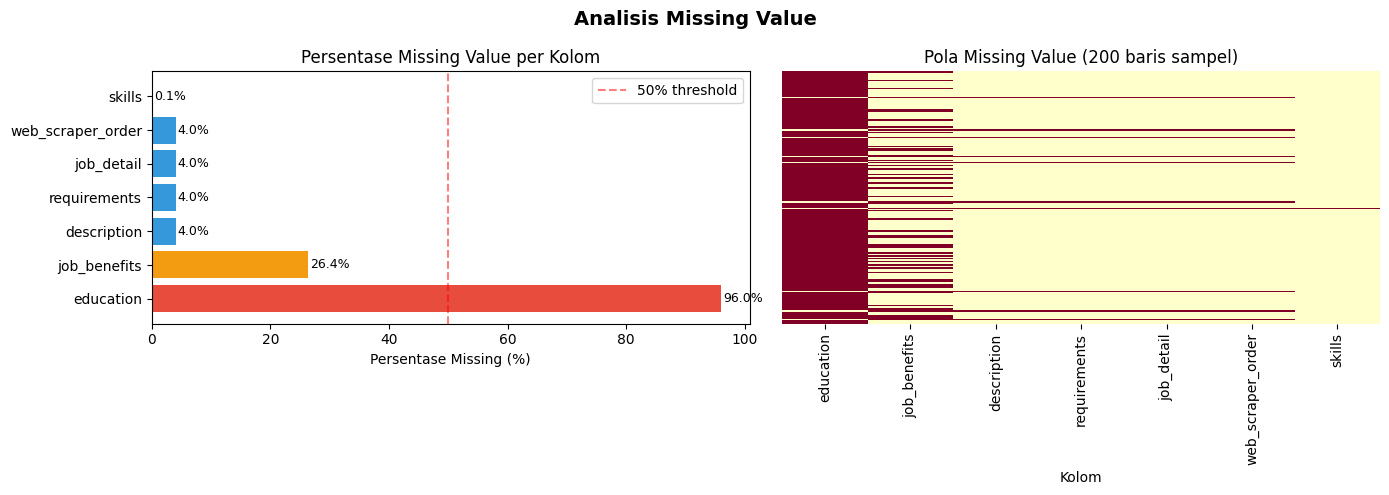

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Anggap 'Not Available' dan 'nan' sebagai missing
tmp = all_df.replace({'Not Available': np.nan, 'nan': np.nan, 'None': np.nan})
missing_pct = (tmp.isnull().sum() / len(tmp) * 100).sort_values(ascending=False)
missing_df  = missing_pct[missing_pct > 0].reset_index()
missing_df.columns = ['Kolom', 'Missing (%)']

print("=== Missing Value per Kolom (%) ===")
print(missing_df.to_string(index=False))

if len(missing_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Analisis Missing Value', fontsize=14, fontweight='bold')

    bar_colors = ['#E74C3C' if v > 50 else '#F39C12' if v > 20 else '#3498DB'
                  for v in missing_df['Missing (%)']]
    axes[0].barh(missing_df['Kolom'], missing_df['Missing (%)'], color=bar_colors)
    axes[0].set_xlabel('Persentase Missing (%)')
    axes[0].set_title('Persentase Missing Value per Kolom')
    axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    axes[0].legend()
    for i, row in missing_df.iterrows():
        axes[0].text(row['Missing (%)'] + 0.3, i, f"{row['Missing (%)']:.1f}%", va='center', fontsize=9)

    sample_tmp = tmp[missing_df['Kolom']].sample(min(200, len(tmp)), random_state=42)
    sns.heatmap(sample_tmp.isnull(), yticklabels=False, cbar=False, cmap='YlOrRd', ax=axes[1])
    axes[1].set_title('Pola Missing Value (200 baris sampel)')
    axes[1].set_xlabel('Kolom')

    plt.tight_layout()
    plt.show()
else:
    print("\nTidak ada missing value pada dataset ini.")

### 5.4 Distribusi Sumber Data & Kategori Pekerjaan

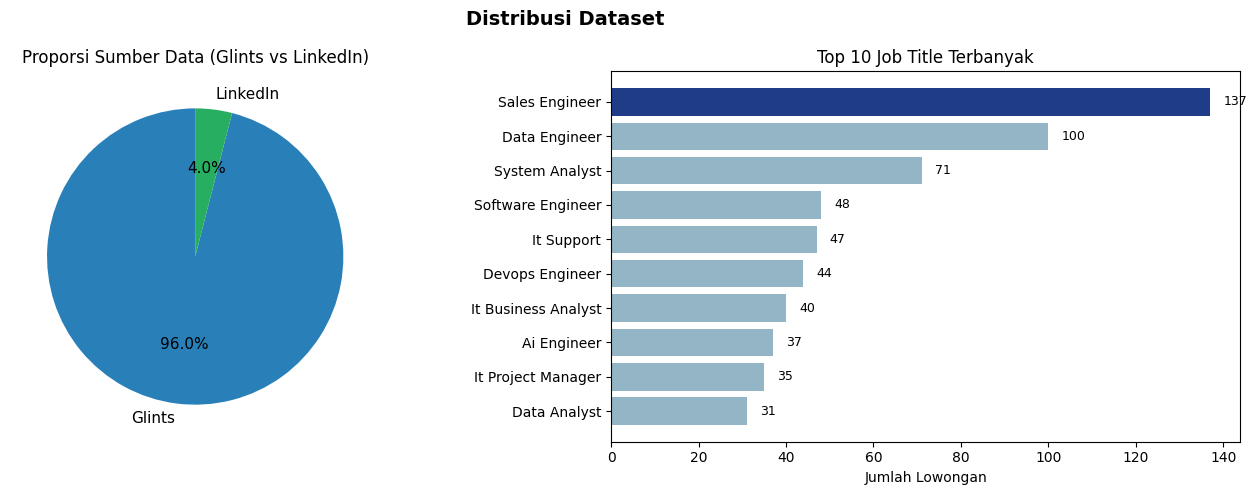

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Dataset', fontsize=14, fontweight='bold')

src_counts = all_df['source'].value_counts()
axes[0].pie(src_counts.values, labels=src_counts.index, autopct='%1.1f%%',
            colors=['#2980B9', '#27AE60'], startangle=90, textprops={'fontsize': 11})
axes[0].set_title('Proporsi Sumber Data (Glints vs LinkedIn)')

top_titles = all_df['job_title'].value_counts().head(10)
colors_bar = ['#1F3C88'] + ['#93B5C6'] * 9
axes[1].barh(top_titles.index[::-1], top_titles.values[::-1], color=colors_bar[::-1])
axes[1].set_title('Top 10 Job Title Terbanyak')
axes[1].set_xlabel('Jumlah Lowongan')
for i, v in enumerate(top_titles.values[::-1]):
    axes[1].text(v + 3, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.5 Distribusi Lokasi & Pendidikan

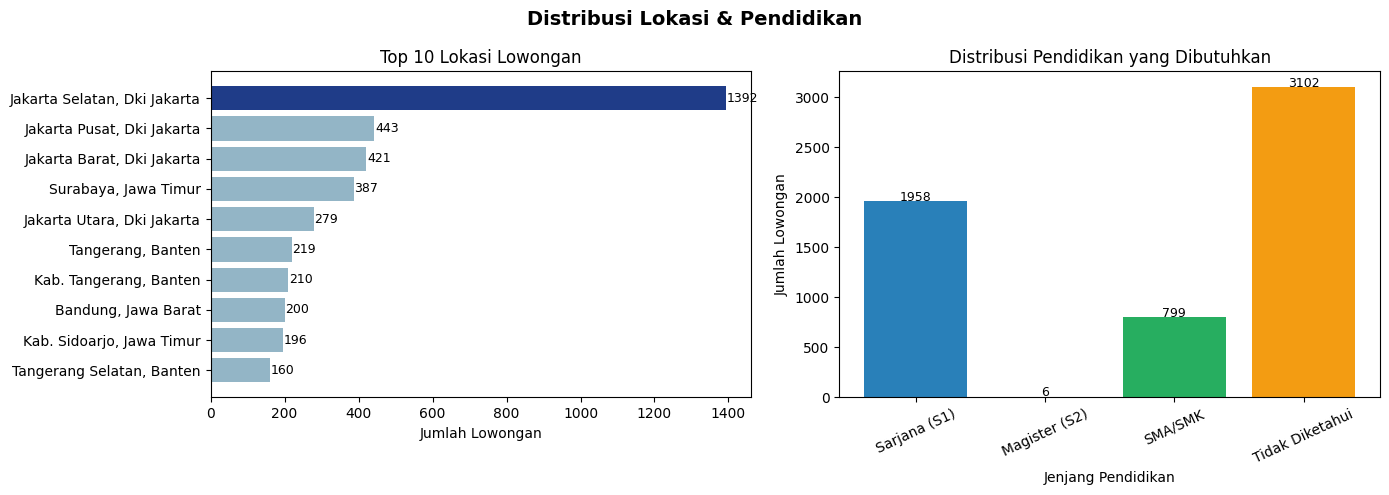

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribusi Lokasi & Pendidikan', fontsize=14, fontweight='bold')

top_loc   = all_df['location'].value_counts().head(10)
colors_loc = ['#1F3C88'] + ['#93B5C6'] * 9
axes[0].barh(top_loc.index[::-1], top_loc.values[::-1], color=colors_loc[::-1])
axes[0].set_title('Top 10 Lokasi Lowongan')
axes[0].set_xlabel('Jumlah Lowongan')
for i, v in enumerate(top_loc.values[::-1]):
    axes[0].text(v + 2, i, str(v), va='center', fontsize=9)

edu_map_quick = {
    r'Minimal Sarjana \(S1\)': 'Sarjana (S1)',
    r'Minimal Magister \(S2\)': 'Magister (S2)',
    r'Minimal Diploma \(D[1-4]\)': 'Diploma (D1-D4)',
    r'Minimal SMA/SMK': 'SMA/SMK',
}

def quick_edu(req):
    if not isinstance(req, str): return 'Tidak Diketahui'
    for pat, label in edu_map_quick.items():
        if re.search(pat, req): return label
    return 'Tidak Diketahui'

if 'requirements' in all_df.columns:
    edu_counts = all_df['requirements'].apply(quick_edu).value_counts()
    order_edu  = ['Sarjana (S1)', 'Magister (S2)', 'Diploma (D1-D4)', 'SMA/SMK', 'Tidak Diketahui']
    edu_ordered = edu_counts.reindex([x for x in order_edu if x in edu_counts.index]).fillna(0)
    axes[1].bar(edu_ordered.index, edu_ordered.values,
                color=['#2980B9','#8E44AD','#27AE60','#F39C12','#BDC3C7'])
    axes[1].set_title('Distribusi Pendidikan yang Dibutuhkan')
    axes[1].set_xlabel('Jenjang Pendidikan')
    axes[1].set_ylabel('Jumlah Lowongan')
    axes[1].tick_params(axis='x', rotation=25)
    for i, v in enumerate(edu_ordered.values):
        axes[1].text(i, v + 3, str(int(v)), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 5.6 Analisis Distribusi Skills

/tmp/ipykernel_1394/329761747.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([sk_g, sk_l], labels=['Glints', 'LinkedIn'],


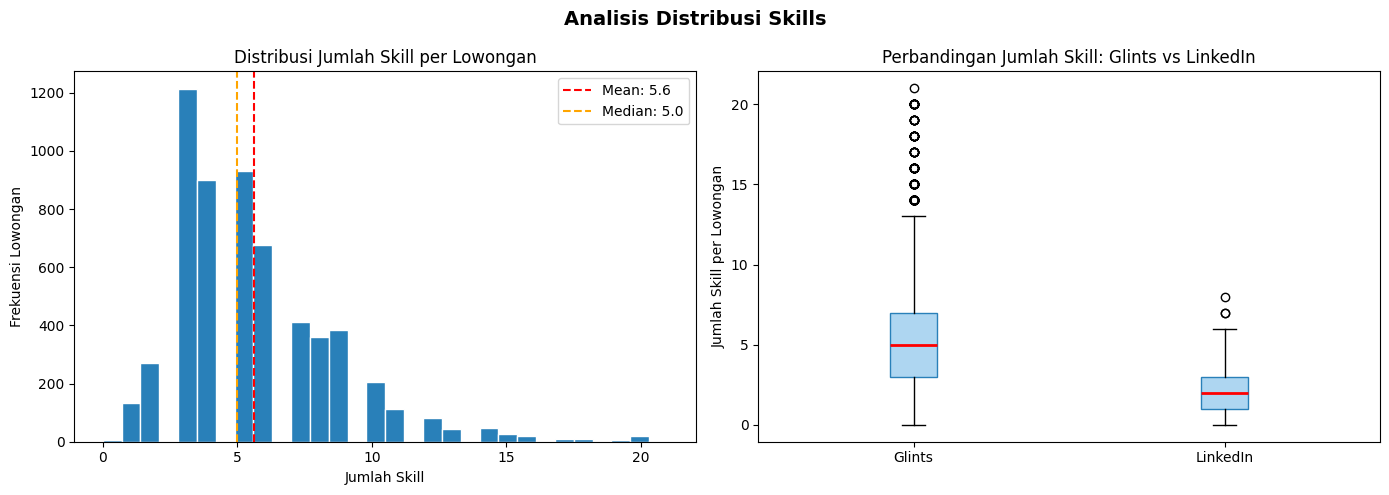


=== Statistik Deskriptif Jumlah Skill per Platform ===
           count  mean   std  min  25%  50%  75%   max
source                                                
Glints    5630.0  5.75  2.98  0.0  3.0  5.0  7.0  21.0
LinkedIn   235.0  2.16  1.45  0.0  1.0  2.0  3.0   8.0


In [23]:
def quick_parse_skills(text):
    if not isinstance(text, str) or text.strip() in ['Not Available', '', 'nan']:
        return []
    text = re.sub(r'^Skills', '', text).strip()
    text = re.sub(r'Coba lanjut melamar.*?dimiliki', '', text).strip()
    text = re.sub(r'Give it a try.*?match your profile', '', text, flags=re.IGNORECASE).strip()
    skills = re.split(r'(?<=[a-z])(?=[A-Z])', text)
    return [s.strip() for s in skills if s.strip() and len(s.strip()) > 1]

all_df['skills_count_eda'] = all_df['skills'].apply(lambda x: len(quick_parse_skills(x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analisis Distribusi Skills', fontsize=14, fontweight='bold')

axes[0].hist(all_df['skills_count_eda'], bins=30, color='#2980B9', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Skill per Lowongan')
axes[0].set_xlabel('Jumlah Skill')
axes[0].set_ylabel('Frekuensi Lowongan')
mean_s = all_df['skills_count_eda'].mean()
med_s  = all_df['skills_count_eda'].median()
axes[0].axvline(mean_s, color='red',    linestyle='--', label=f'Mean: {mean_s:.1f}')
axes[0].axvline(med_s,  color='orange', linestyle='--', label=f'Median: {med_s:.1f}')
axes[0].legend()

sk_g = all_df[all_df['source']=='Glints']['skills_count_eda']
sk_l = all_df[all_df['source']=='LinkedIn']['skills_count_eda']
axes[1].boxplot([sk_g, sk_l], labels=['Glints', 'LinkedIn'],
                patch_artist=True,
                boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Perbandingan Jumlah Skill: Glints vs LinkedIn')
axes[1].set_ylabel('Jumlah Skill per Lowongan')

plt.tight_layout()
plt.show()

print("\n=== Statistik Deskriptif Jumlah Skill per Platform ===")
print(all_df.groupby('source')['skills_count_eda'].describe().round(2).to_string())

### 5.7 Deteksi Outlier & Korelasi

Outlier terdeteksi: 137 baris (2.3%)


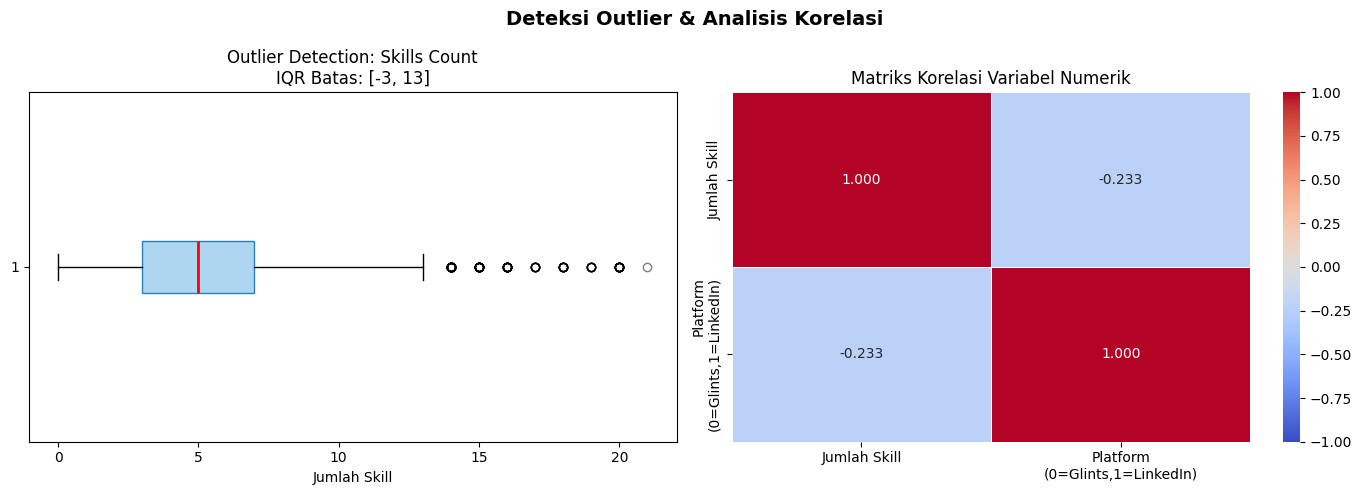

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deteksi Outlier & Analisis Korelasi', fontsize=14, fontweight='bold')

Q1  = all_df['skills_count_eda'].quantile(0.25)
Q3  = all_df['skills_count_eda'].quantile(0.75)
IQR = Q3 - Q1
lower_b = Q1 - 1.5 * IQR
upper_b = Q3 + 1.5 * IQR
outliers = all_df[(all_df['skills_count_eda'] < lower_b) | (all_df['skills_count_eda'] > upper_b)]

axes[0].boxplot(all_df['skills_count_eda'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#AED6F1', color='#2980B9'),
                medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', color='#E74C3C', alpha=0.5))
axes[0].set_title(f'Outlier Detection: Skills Count\n'
                  f'IQR Batas: [{lower_b:.0f}, {upper_b:.0f}]')
axes[0].set_xlabel('Jumlah Skill')
print(f"Outlier terdeteksi: {len(outliers):,} baris ({len(outliers)/len(all_df)*100:.1f}%)")

all_df['source_num'] = (all_df['source'] == 'LinkedIn').astype(int)
corr = all_df[['skills_count_eda', 'source_num']].corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            center=0, ax=axes[1], linewidths=0.5,
            xticklabels=['Jumlah Skill', 'Platform\n(0=Glints,1=LinkedIn)'],
            yticklabels=['Jumlah Skill', 'Platform\n(0=Glints,1=LinkedIn)'])
axes[1].set_title('Matriks Korelasi Variabel Numerik')

plt.tight_layout()
plt.show()

### 5.8 Ringkasan Temuan EDA

Berdasarkan eksplorasi data di atas, diperoleh beberapa insight awal:

- **Sumber data** didominasi Glints; LinkedIn menjadi sumber sekunder dengan jumlah lebih kecil
- **Lokasi** lowongan kerja IT masih sangat terkonsentrasi di kota-kota besar, terutama Jakarta
- **Pendidikan** yang paling banyak disyaratkan adalah Sarjana (S1)
- **Distribusi skills** bersifat *right-skewed* — mayoritas lowongan memiliki sedikit atau tidak ada skill tercantum, dengan sebagian kecil memiliki banyak skill (outlier)
- **Perbedaan platform**: Glints dan LinkedIn menunjukkan pola yang berbeda pada pencantuman skill dan syarat pendidikan — ini akan diuji secara statistik pada tahap **A/B Testing**


## 6. Simpan Intermediate (sebelum skills clean)

In [25]:
all_df.to_csv("all_data_clean.csv", index=False)
print("Tersimpan: all_data_clean.csv")

Tersimpan: all_data_clean.csv


## 7. Bersihkan Kolom Skills

**Format skills berbeda per sumber:**
- **Glints**: skills digabung tanpa separator → split di batas huruf kecil→kapital
- **LinkedIn**: skills dipisah newline `\n` antar kalimat

In [26]:
def clean_skills_glints(text):
    """Bersihkan skills dari Glints yang digabung tanpa separator."""
    if pd.isna(text) or text == 'Not Available':
        return 'Not Available'

    text = str(text).strip()

    # Hapus prefix 'Skills'
    text = re.sub(r'^Skills', '', text, flags=re.IGNORECASE).strip()

    # Hapus kalimat 'Give it a try! / Coba lanjut melamar - X of Y skills match'
    text = re.sub(
        r'Give it a try! - \d+ of \d+ skills match your profile',
        '', text, flags=re.IGNORECASE
    ).strip()
    text = re.sub(
        r'Coba lanjut melamar - \d+ dari \d+ dimiliki',
        '', text, flags=re.IGNORECASE
    ).strip()

    # Split di batas lowercase→uppercase
    skills = re.split(r'(?<=[a-z])(?=[A-Z])', text)
    skills = [s.strip() for s in skills if s.strip()]

    return ' | '.join(skills) if skills else 'Not Available'


def clean_skills_linkedin(text):
    """Bersihkan skills dari LinkedIn yang dipisah newline."""
    if pd.isna(text) or text == 'Not Available':
        return 'Not Available'

    skills = [s.strip() for s in str(text).split('\n') if s.strip()]

    return ' | '.join(skills) if skills else 'Not Available'


all_df['skills_clean'] = all_df.apply(
    lambda row: clean_skills_glints(row['skills'])  if row['source'] == 'Glints'
           else clean_skills_linkedin(row['skills']),
    axis=1
)

# Preview hasil
print("=== Glints skills sample ===")
print(all_df[all_df['source'] == 'Glints'][['skills', 'skills_clean']].head(3).to_string())

print("\n=== LinkedIn skills sample ===")
print(all_df[all_df['source'] == 'LinkedIn'][['skills', 'skills_clean']].head(3).to_string())

=== Glints skills sample ===
                                                                                                                                                                                 skills                                                                                                                                                    skills_clean
0                                                                                                                           SkillsPlumbingMaintenance EngineeringElectrical Maintenance                                                                                                     Plumbing | Maintenance Engineering | Electrical Maintenance
1                                                 SkillsDigital MarketingGoogle AnalyticsGoogle AdsMarketing CommunicationsCRMKPI ReportsMeta AdsLeadsContent MarketingContent Strategy         Digital Marketing | Google Analytics | Google Ads | Marketing Communications | CRMKPI Repor

## 8. Ekstrak & Normalisasi Kolom Education

**Strategi:**
- LinkedIn sudah punya kolom `education` (dari kolom `description` asli)
- Glints diekstrak dari kolom `requirements`
- Semua label dinormalisasi ke kategori standar yang konsisten

In [27]:
import pandas as pd
import re

# Load file intermediate
df = pd.read_csv("all_data_clean.csv")
df = df[df['web_scraper_order'] != 'web_scraper_start_url']

print("Shape loaded:", df.shape)

Shape loaded: (5865, 14)


In [28]:
edu_map_glints = {
    r'Minimal SD'                             : 'SD',
    r'Minimal SMP'                            : 'SMP',
    r'Minimal SMA/SMK'                        : 'SMA/SMK',
    r'Minimal Diploma \(D[1-4]\)'             : 'Diploma (D1-D4)',
    r'Minimal Sarjana \(S1\)'                 : 'Sarjana (S1)',
    r'Minimal Magister \(S2\)'                : 'Magister (S2)',
    r'Minimal Pendidikan Profesi'             : 'Pendidikan Profesi',
    r'Minimum Associate Degree'               : 'Diploma (D1-D4)',   # D3 = bagian dari D1-D4
    r'Minimum Primary School'                 : 'SD',
    r'Minimum Secondary School'               : 'SMP',
    r'Minimum Professional Education Program' : 'Pendidikan Profesi',
}

edu_map_linkedin = {
    r'S2|Master|Magister'                   : 'Magister (S2)',
    r'D[1-4]|Diploma'                       : 'Diploma (D1-D4)',
    r"Bachelor|S1|Sarjana|bachelor's"       : 'Sarjana (S1)',
    r'SMA|SMK|High School|Vocational'       : 'SMA/SMK',
    r'SMP|Junior High'                      : 'SMP',
    r'SD|Primary School|Elementary'         : 'SD',
}

normalisasi = {
    # Singkatan → label standar
    'S1'                       : 'Sarjana (S1)',
    'D4/S1'                    : 'Sarjana (S1)',
    'S2'                       : 'Magister (S2)',
    'D3'                       : 'Diploma (D1-D4)',
    'D4'                       : 'Diploma (D1-D4)',
    'SMA'                      : 'SMA/SMK',
    'SMK'                      : 'SMA/SMK',
    # Duplikat label lama → label standar
    'Associate Degree (D3)'    : 'Diploma (D1-D4)',
    'Primary School (SD)'      : 'SD',
    'Secondary School'         : 'SMP',
    'Professional Education Program' : 'Pendidikan Profesi',
}

print("Pola normalisasi siap.")

Pola normalisasi siap.


In [29]:
def extract_education(row):
    """
    Ekstrak jenjang pendidikan dari baris data.
    Urutan prioritas:
    1. Normalisasi langsung jika nilainya sudah ada tapi format berbeda
    2. Cari dari kolom requirements (Glints)
    3. Cari dari kolom description/requirements (LinkedIn fallback)
    4. Kembalikan 'Not Available' jika tidak ditemukan
    """
    edu = str(row.get('education', '')).strip()

    if edu in normalisasi:
        return normalisasi[edu]

    if re.match(r'^S1\b', edu, re.IGNORECASE):
        return 'Sarjana (S1)'
    if re.match(r'^S2\b', edu, re.IGNORECASE):
        return 'Magister (S2)'

    label_standar = {
        'Sarjana (S1)', 'Magister (S2)', 'Diploma (D1-D4)',
        'SMA/SMK', 'SMP', 'SD', 'Pendidikan Profesi'
    }
    if edu in label_standar:
        return edu

    req = str(row.get('requirements', ''))
    for pattern, label in edu_map_glints.items():
        if re.search(pattern, req):
            return label

    # --- Tahap 5: Fallback cari di description + requirements (LinkedIn) ---
    desc = str(row.get('description', ''))
    text_gabung = desc + ' ' + req
    for pattern, label in edu_map_linkedin.items():
        if re.search(pattern, text_gabung, re.IGNORECASE):
            return label

    return 'Not Available'

df['education'] = df.apply(extract_education, axis=1)

print("=== Distribusi Education ===")
print(df['education'].value_counts())
print(f"\nTotal data          : {len(df)}")
print(f"Berhasil terisi     : {(df['education'] != 'Not Available').sum()}")
print(f"Not Available       : {(df['education'] == 'Not Available').sum()}")

=== Distribusi Education ===
education
Sarjana (S1)          3117
Diploma (D1-D4)       1606
SMA/SMK                979
Magister (S2)          126
SD                      14
SMP                     13
Pendidikan Profesi       9
Not Available            1
Name: count, dtype: int64

Total data          : 5865
Berhasil terisi     : 5864
Not Available       : 1


In [30]:
label_standar = {
    'Sarjana (S1)', 'Magister (S2)', 'Diploma (D1-D4)',
    'SMA/SMK', 'SMP', 'SD', 'Pendidikan Profesi', 'Not Available'
}

label_unik = set(df['education'].unique())
label_aneh = label_unik - label_standar

if label_aneh:
    print(f"⚠️  Masih ada {len(label_aneh)} label tidak standar:")
    for lb in sorted(label_aneh):
        print(f"   - '{lb}' ({(df['education'] == lb).sum()} baris)")
else:
    print("✅ Semua label education sudah standar dan konsisten!")

✅ Semua label education sudah standar dan konsisten!


In [31]:
# Ringkasan akhir distribusi education
print("=== Distribusi Education Final ===")
edu_counts = df['education'].value_counts()
print(edu_counts)
print(f"\nTotal unique label : {df['education'].nunique()}")

=== Distribusi Education Final ===
education
Sarjana (S1)          3117
Diploma (D1-D4)       1606
SMA/SMK                979
Magister (S2)          126
SD                      14
SMP                     13
Pendidikan Profesi       9
Not Available            1
Name: count, dtype: int64

Total unique label : 8


## 9. Simpan Dataset Final

In [32]:
df.to_csv("all_data_clean_final2.csv", index=False)
print("✅ Dataset final tersimpan: all_data_clean_final2.csv")
print("Shape :", df.shape)
print("Kolom :", df.columns.tolist())

✅ Dataset final tersimpan: all_data_clean_final2.csv
Shape : (5865, 14)
Kolom : ['web_scraper_order', 'web_scraper_start_url', 'job_title', 'company', 'location', 'job_detail', 'description', 'requirements', 'skills', 'job_benefits', 'source', 'education', 'skills_count_eda', 'source_num']


In [33]:
# Cek null final
print("=== Null Values Final ===")
print(df.isnull().sum())
print(f"\nTotal null keseluruhan: {df.isnull().sum().sum()}")

=== Null Values Final ===
web_scraper_order        0
web_scraper_start_url    0
job_title                0
company                  0
location                 0
job_detail               0
description              0
requirements             0
skills                   0
job_benefits             0
source                   0
education                0
skills_count_eda         0
source_num               0
dtype: int64

Total null keseluruhan: 0


---
# Preprocessing
Menyiapkan dataset final.

**4 tahap:**
1. Parse & simpan kolom `skills_clean`
2. Cek & flag duplikat job+company+lokasi
3. Feature engineering (encoding + ekstrak provinsi + hitung skill)
4. Simpan CSV final + buat Data Dictionary

## 10. Parse & Simpan `skills_clean`

In [34]:
def parse_skills_glints(text):
    """Parse skills Glints — split di batas lowercase→uppercase."""
    if pd.isna(text) or str(text).strip() in ['Not Available', '']:
        return 'Not Available'
    text = str(text).strip()
    text = re.sub(r'^Skills', '', text).strip()
    text = re.sub(r'Coba lanjut melamar.*?dimiliki', '', text).strip()
    text = re.sub(r'Give it a try.*?match your profile', '', text, flags=re.IGNORECASE).strip()
    text = re.sub(r'\byour profile\b', '', text, flags=re.IGNORECASE).strip()
    skills = re.split(r'(?<=[a-z])(?=[A-Z])', text)
    skills = [s.strip() for s in skills if s.strip() and len(s.strip()) > 1]
    return ' | '.join(skills) if skills else 'Not Available'


def parse_skills_linkedin(text):
    """Parse skills LinkedIn — split di newline."""
    if pd.isna(text) or str(text).strip() in ['Not Available', '']:
        return 'Not Available'
    skills = [s.strip() for s in str(text).split('\n') if s.strip()]
    return ' | '.join(skills) if skills else 'Not Available'


df['skills_clean'] = df.apply(
    lambda row: parse_skills_glints(row['skills']) if row['source'] == 'Glints'
           else parse_skills_linkedin(row['skills']),
    axis=1
)

not_avail = (df['skills_clean'] == 'Not Available').sum()
print(f'Contoh skills_clean Glints   : {df[df["source"]=="Glints"]["skills_clean"].iloc[0][:80]}')
print(f'Contoh skills_clean LinkedIn : {df[df["source"]=="LinkedIn"]["skills_clean"].iloc[0][:80]}')
print(f'Not Available                : {not_avail} baris ({not_avail/len(df)*100:.1f}%)')

Contoh skills_clean Glints   : Plumbing | Maintenance Engineering | Electrical Maintenance
Contoh skills_clean LinkedIn : Basic understanding of software development lifecycle (SDLC) and quality assuran
Not Available                : 6 baris (0.1%)


## 11. Flag Duplikat job+company+lokasi

In [35]:
df['is_duplicate_job'] = df.duplicated(
    subset=['job_title', 'company', 'location'], keep='first'
).astype(int)  # 0 = unik/first occurrence, 1 = duplikat

total_dup = df['is_duplicate_job'].sum()
print(f'Baris di-flag duplikat : {total_dup} ({total_dup/len(df)*100:.1f}%)')
print(f'Baris unik             : {len(df) - total_dup}')
print('\nTop 5 kombinasi paling sering duplikat:')
print(
    df[df['is_duplicate_job']==1]
    .groupby(['job_title','company','location'])
    .size()
    .sort_values(ascending=False)
    .head(5)
    .to_string()
)

Baris di-flag duplikat : 2188 (37.3%)
Baris unik             : 3677

Top 5 kombinasi paling sering duplikat:
job_title                                            company                      location                    
Network Infrastructure - Telecommunication Industry  Pt Sigma Global Teknologi    Jakarta Selatan, Dki Jakarta    7
Senior Sales Engineer                                Pt Terada Teknika Indonesia  Kab. Bekasi, Jawa Barat         7
Data Engineer                                        Pt Sigma Global Teknologi    Jakarta Selatan, Dki Jakarta    7
Etl Developer                                        Pt Sigma Global Teknologi    Jakarta Barat, Dki Jakarta      6
Etl Developer (Contract Based)                       Pt Sigma Global Teknologi    Jakarta Selatan, Dki Jakarta    5


## 12. Feature Engineering

In [36]:
# ── Ekstrak Provinsi ────────────────────────────────────────────
def extract_province(loc):
    if pd.isna(loc) or str(loc).strip() in ['Not Available', '']:
        return 'Tidak Diketahui'
    parts = str(loc).split(',')
    return parts[-1].strip() if len(parts) >= 2 else str(loc).strip()

df['province'] = df['location'].apply(extract_province)

# ── Ordinal Encoding Education ──────────────────────────────────
education_order = {
    'Not Available'     : 0,
    'SD'                : 1,
    'SMP'               : 2,
    'SMA/SMK'           : 3,
    'Diploma (D1-D4)'   : 4,
    'Pendidikan Profesi': 5,
    'Sarjana (S1)'      : 6,
    'Magister (S2)'     : 7,
}
df['education_encoded'] = df['education'].map(education_order).fillna(0).astype(int)

# ── Binary Encoding Source ──────────────────────────────────────
df['source_encoded'] = (df['source'] == 'LinkedIn').astype(int)
# 0 = Glints, 1 = LinkedIn

# ── Hitung Jumlah Skill per Lowongan ────────────────────────────
def count_skills(text):
    if pd.isna(text) or str(text).strip() in ['Not Available', '']:
        return 0
    return len([s for s in str(text).split(' | ') if s.strip()])

df['skills_count'] = df['skills_clean'].apply(count_skills)

# ── Ringkasan ───────────────────────────────────────────────────
print('=== Distribusi Provinsi (Top 10) ===')
print(df['province'].value_counts().head(10))
print('\n=== Education Encoding ===')
print(df.groupby(['education','education_encoded']).size().reset_index(name='count').sort_values('education_encoded').to_string(index=False))
print(f'\nRata-rata jumlah skill per lowongan : {df["skills_count"].mean():.1f}')

=== Distribusi Provinsi (Top 10) ===
province
Dki Jakarta                  2692
Jawa Timur                    824
Jawa Barat                    642
Banten                        611
Di Yogyakarta                 222
Jawa Tengah                   194
Indonesia                     181
Bali                          175
Kepulauan Riau                 71
Jakarta Metropolitan Area      43
Name: count, dtype: int64

=== Education Encoding ===
         education  education_encoded  count
     Not Available                  0      1
                SD                  1     14
               SMP                  2     13
           SMA/SMK                  3    979
   Diploma (D1-D4)                  4   1606
Pendidikan Profesi                  5      9
      Sarjana (S1)                  6   3117
     Magister (S2)                  7    126

Rata-rata jumlah skill per lowongan : 5.6


## 13. Simpan CSV Final untuk Tim AI

In [43]:
col_order = [
    'web_scraper_order', 'web_scraper_start_url', 'source', 'source_encoded',
    'job_title', 'company', 'location', 'province',
    'job_detail', 'description', 'requirements', 'job_benefits',
    'skills', 'skills_clean', 'skills_count',
    'education', 'education_encoded',
    'is_duplicate_job',
]
col_order = [c for c in col_order if c in df.columns]
df_final = df[col_order]

df_final.to_csv('all_data_final.csv', index=False)
print('✅ Tersimpan: all_data_final_for_AI.csv')
print(f'Shape  : {df_final.shape}')
print(f'Kolom  : {df_final.columns.tolist()}')
print(f'\nNull per kolom:')
print(df_final.isnull().sum())

✅ Tersimpan: all_data_final_for_AI.csv
Shape  : (5865, 18)
Kolom  : ['web_scraper_order', 'web_scraper_start_url', 'source', 'source_encoded', 'job_title', 'company', 'location', 'province', 'job_detail', 'description', 'requirements', 'job_benefits', 'skills', 'skills_clean', 'skills_count', 'education', 'education_encoded', 'is_duplicate_job']

Null per kolom:
web_scraper_order        0
web_scraper_start_url    0
source                   0
source_encoded           0
job_title                0
company                  0
location                 0
province                 0
job_detail               0
description              0
requirements             0
job_benefits             0
skills                   0
skills_clean             0
skills_count             0
education                0
education_encoded        0
is_duplicate_job         0
dtype: int64


## 14. Buat Data Dictionary

In [44]:
data_dict = pd.DataFrame([
    {'Kolom': 'web_scraper_order',    'Tipe': 'string',                  'Deskripsi': 'ID unik hasil scraping dari web scraper',                                                                              'Contoh Nilai': '1779164489-1',                                   'Nilai Kosong': 'Not Available'},
    {'Kolom': 'web_scraper_start_url','Tipe': 'string',                  'Deskripsi': 'URL halaman lowongan kerja yang di-scrape',                                                                            'Contoh Nilai': 'https://glints.com/id/...',                       'Nilai Kosong': 'Not Available'},
    {'Kolom': 'source',               'Tipe': 'string (kategorikal)',     'Deskripsi': 'Platform asal data lowongan',                                                                                         'Contoh Nilai': 'Glints | LinkedIn',                              'Nilai Kosong': '-'},
    {'Kolom': 'source_encoded',       'Tipe': 'integer (binary)',         'Deskripsi': 'Encoding kolom source. 0 = Glints, 1 = LinkedIn',                                                                    'Contoh Nilai': '0 | 1',                                          'Nilai Kosong': '-'},
    {'Kolom': 'job_title',            'Tipe': 'string',                  'Deskripsi': 'Nama posisi/jabatan pada lowongan pekerjaan',                                                                         'Contoh Nilai': 'Data Analyst | Software Engineer',               'Nilai Kosong': '-'},
    {'Kolom': 'company',              'Tipe': 'string',                  'Deskripsi': 'Nama perusahaan yang membuka lowongan',                                                                               'Contoh Nilai': 'Pt Gojek Indonesia',                             'Nilai Kosong': '-'},
    {'Kolom': 'location',             'Tipe': 'string',                  'Deskripsi': 'Lokasi lengkap lowongan (kota/kabupaten + provinsi)',                                                                 'Contoh Nilai': 'Jakarta Selatan, Dki Jakarta',                   'Nilai Kosong': '-'},
    {'Kolom': 'province',             'Tipe': 'string (kategorikal)',     'Deskripsi': 'Provinsi yang diekstrak dari kolom location',                                                                        'Contoh Nilai': 'Dki Jakarta | Jawa Timur | Jawa Barat',          'Nilai Kosong': 'Tidak Diketahui'},
    {'Kolom': 'job_detail',           'Tipe': 'string (teks panjang)',    'Deskripsi': 'URL detail atau ringkasan lowongan',                                                                                 'Contoh Nilai': 'https://glints.com/id/...',                       'Nilai Kosong': 'Not Available'},
    {'Kolom': 'description',          'Tipe': 'string (teks panjang)',    'Deskripsi': 'Deskripsi lengkap pekerjaan dan tanggung jawab',                                                                     'Contoh Nilai': 'Bertanggung jawab dalam pengelolaan data...',     'Nilai Kosong': 'Not Available'},
    {'Kolom': 'requirements',         'Tipe': 'string (teks panjang)',    'Deskripsi': 'Persyaratan pendidikan, pengalaman, dan kualifikasi',                                                                'Contoh Nilai': 'Minimal Sarjana (S1), pengalaman 2 tahun...',     'Nilai Kosong': 'Not Available'},
    {'Kolom': 'job_benefits',         'Tipe': 'string (teks panjang)',    'Deskripsi': 'Tunjangan dan benefit yang ditawarkan perusahaan',                                                                   'Contoh Nilai': 'THR | Health Insurance | Work Insurance',         'Nilai Kosong': 'Not Available'},
    {'Kolom': 'skills',               'Tipe': 'string (teks mentah)',     'Deskripsi': 'Skill mentah hasil scraping sebelum dibersihkan. Format tidak konsisten antar sumber.',                              'Contoh Nilai': 'SkillsPythonSQL (Glints) | Python\nSQL (LinkedIn)','Nilai Kosong': 'Not Available'},
    {'Kolom': 'skills_clean',         'Tipe': 'string (dipisah pipe |)',  'Deskripsi': 'Skill yang sudah dibersihkan dan distandarisasi. Setiap skill dipisah dengan " | "',                                 'Contoh Nilai': 'Python | SQL | Machine Learning | Pandas',         'Nilai Kosong': 'Not Available'},
    {'Kolom': 'skills_count',         'Tipe': 'integer',                  'Deskripsi': 'Jumlah skill yang tercantum pada lowongan',                                                                          'Contoh Nilai': '0 - 20+',                                        'Nilai Kosong': '0'},
    {'Kolom': 'education',            'Tipe': 'string (kategorikal)',     'Deskripsi': 'Jenjang pendidikan minimum yang dibutuhkan',                                                                         'Contoh Nilai': 'Sarjana (S1) | Diploma (D1-D4) | SMA/SMK',       'Nilai Kosong': 'Not Available'},
    {'Kolom': 'education_encoded',    'Tipe': 'integer (ordinal)',        'Deskripsi': 'Ordinal encoding jenjang pendidikan. 0=Tdk diketahui, 1=SD, 2=SMP, 3=SMA/SMK, 4=Diploma, 5=Profesi, 6=S1, 7=S2',   'Contoh Nilai': '0 - 7',                                          'Nilai Kosong': '0'},
    {'Kolom': 'is_duplicate_job',     'Tipe': 'integer (binary flag)',    'Deskripsi': 'Flag duplikat berdasarkan kombinasi job_title+company+location. 0=unik/pertama muncul, 1=duplikat',                  'Contoh Nilai': '0 | 1',                                          'Nilai Kosong': '-'},
])

pd.set_option('display.max_colwidth', 80)
display(data_dict)

data_dict.to_csv('data_dictionary.csv', index=False)
print('\n✅ Data Dictionary tersimpan: data_dictionary.csv')

,Kolom,Tipe,Deskripsi,Contoh Nilai,Nilai Kosong
0,web_scraper_order,string,ID unik hasil scraping dari web scraper,1779164489-1,Not Available
1,web_scraper_start_url,string,URL halaman lowongan kerja yang di-scrape,https://glints.com/id/...,Not Available
2,source,string (kategorikal),Platform asal data lowongan,Glints | LinkedIn,-
3,source_encoded,integer (binary),"Encoding kolom source. 0 = Glints, 1 = LinkedIn",0 | 1,-
4,job_title,string,Nama posisi/jabatan pada lowongan pekerjaan,Data Analyst | Software Engineer,-
5,company,string,Nama perusahaan yang membuka lowongan,Pt Gojek Indonesia,-
6,location,string,Lokasi lengkap lowongan (kota/kabupaten + provinsi),"Jakarta Selatan, Dki Jakarta",-
7,province,string (kategorikal),Provinsi yang diekstrak dari kolom location,Dki Jakarta | Jawa Timur | Jawa Barat,Tidak Diketahui
8,job_detail,string (teks panjang),URL detail atau ringkasan lowongan,https://glints.com/id/...,Not Available
9,description,string (teks panjang),Deskripsi lengkap pekerjaan dan tanggung jawab,Bertanggung jawab dalam pengelolaan data...,Not Available



✅ Data Dictionary tersimpan: data_dictionary.csv


## Ringkasan Akhir

In [45]:
print('=' * 55)
print('       RINGKASAN DATASET FINAL UNTUK TIM AI')
print('=' * 55)
print(f'Total baris              : {len(df_final):,}')
print(f'Total kolom              : {len(df_final.columns)}')
print(f'Baris unik (no duplikat) : {(df_final["is_duplicate_job"]==0).sum():,}')
print(f'Baris di-flag duplikat   : {(df_final["is_duplicate_job"]==1).sum():,}')
print(f'Null values total        : {df_final.isnull().sum().sum()}')
print()
print('Kolom baru yang ditambahkan:')
print('  skills_clean       — skills sudah diparse & distandarisasi')
print('  skills_count       — jumlah skill per lowongan')
print('  province           — provinsi diekstrak dari location')
print('  education_encoded  — ordinal encoding jenjang pendidikan')
print('  source_encoded     — binary encoding sumber data')
print('  is_duplicate_job   — flag duplikat job+company+location')
print()
print('File yang dihasilkan:')
print('  all_data_final.csv')
print('  data_dictionary.csv')
print('=' * 55)

       RINGKASAN DATASET FINAL UNTUK TIM AI
Total baris              : 5,865
Total kolom              : 18
Baris unik (no duplikat) : 3,677
Baris di-flag duplikat   : 2,188
Null values total        : 0

Kolom baru yang ditambahkan:
  skills_clean       — skills sudah diparse & distandarisasi
  skills_count       — jumlah skill per lowongan
  province           — provinsi diekstrak dari location
  education_encoded  — ordinal encoding jenjang pendidikan
  source_encoded     — binary encoding sumber data
  is_duplicate_job   — flag duplikat job+company+location

File yang dihasilkan:
  all_data_final.csv
  data_dictionary.csv


# Visualization & Explanatory Analysis


### Pertanyaan 1: Apa saja skill yang paling banyak dibutuhkan perusahaan berdasarkan data lowongan kerja di bidang IT?

Total skills terkumpul : 32885
Unique skills          : 3488
Unique hard skills     : 3461

Top 10 Semua Skill:
               Skill  Jumlah
Communication Skills     653
    Customer Service     613
     Microsoft Excel     610
    Microsoft Office     589
            Teamwork     578
          IT Support     533
   Technical Support     448
     Troubleshooting     419
      Administration     407
 Sales and Marketing     391

Top 10 Hard Skill:
                  Skill  Jumlah
             IT Support     533
      Technical Support     448
        Troubleshooting     419
Network Troubleshooting     381
                 Python     350
                 Script     337
                   Java     323
   Hardware Maintenance     280
             Data Entry     271
          Data Analysis     264


/tmp/ipykernel_1394/1441672547.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_all, x='Jumlah', y='Skill', palette='Blues_r', ax=axes[0, 0])
/tmp/ipykernel_1394/1441672547.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_hard, x='Jumlah', y='Skill', palette='Oranges_r', ax=axes[0, 1])


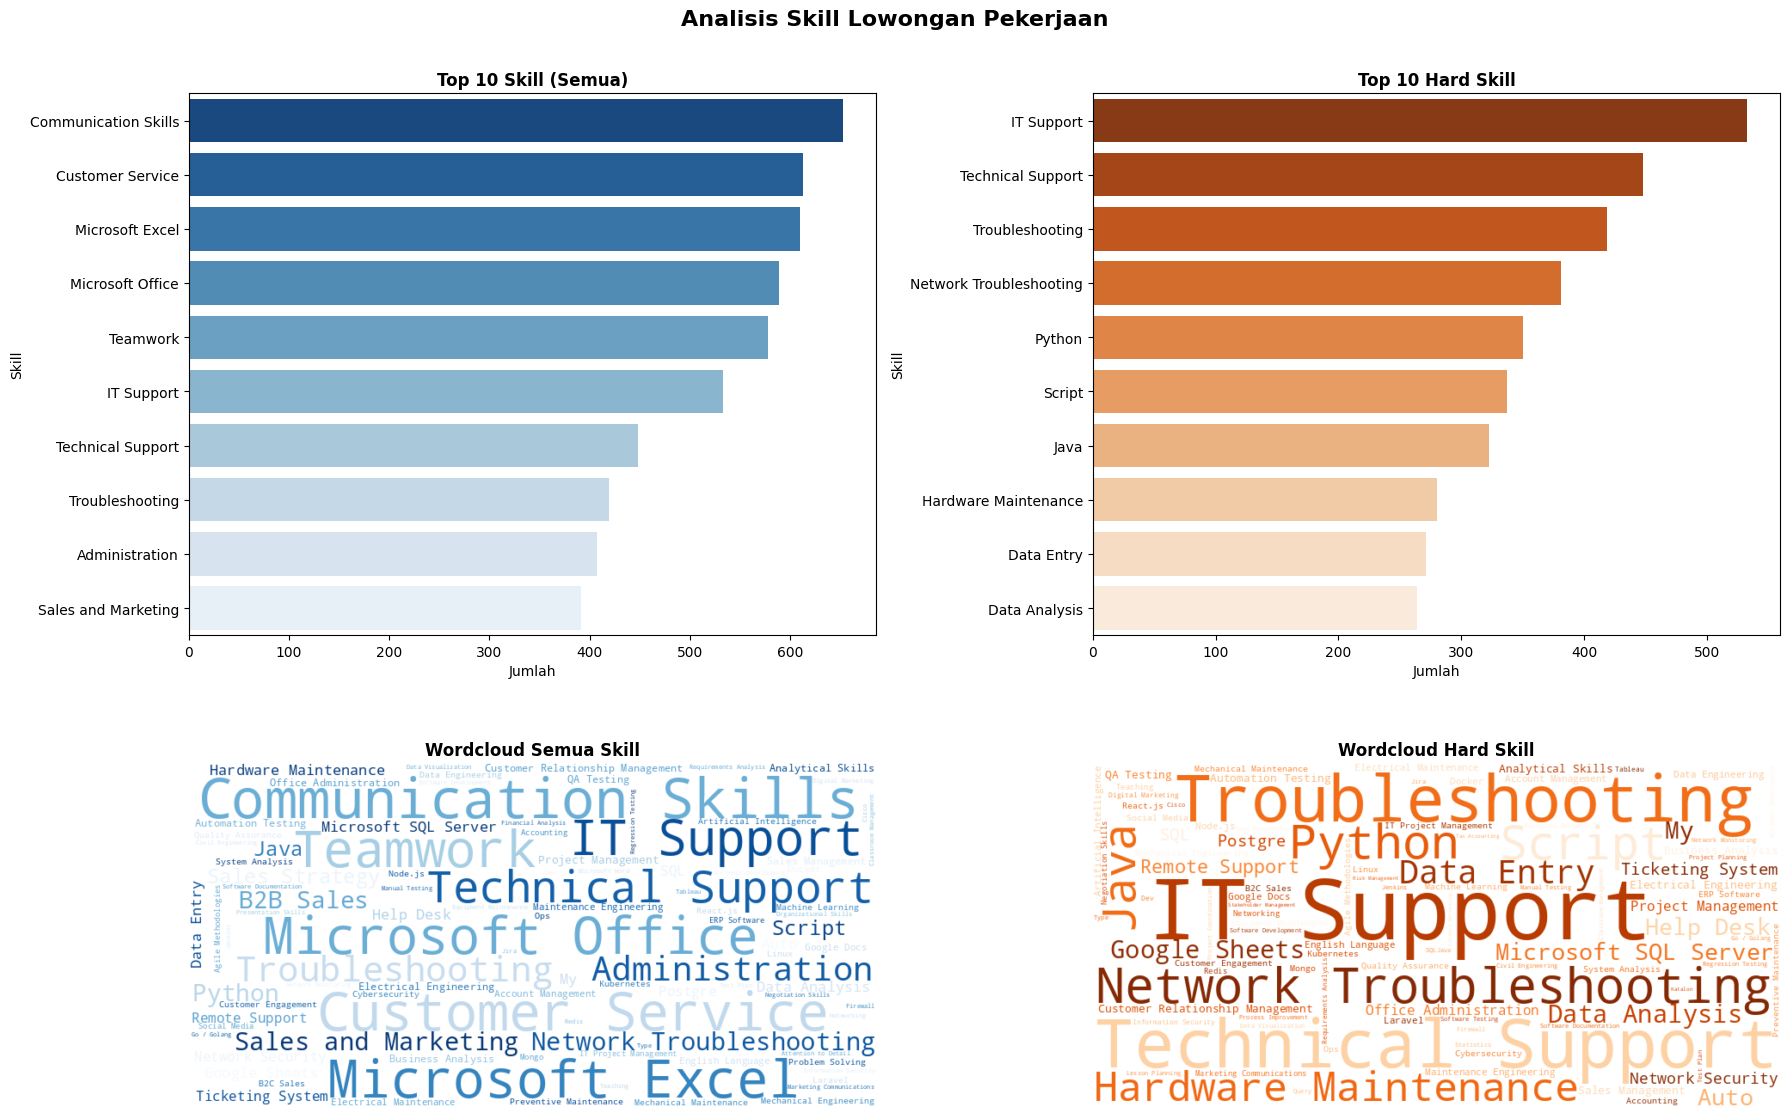


Berdasarkan 5865 data lowongan pekerjaan:

[Semua Skill]
  1. Communication Skills (653 lowongan)
  2. Customer Service (613 lowongan)
  3. Microsoft Excel (610 lowongan)

[Hard Skill Teknis]
  1. IT Support (533 lowongan)
  2. Technical Support (448 lowongan)
  3. Troubleshooting (419 lowongan)

Hard skill teknis menunjukkan kebutuhan spesifik industri teknologi,
sementara soft skill tetap relevan lintas bidang pekerjaan.



In [46]:
import pandas as pd
import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD DATASET
df = pd.read_csv('all_data_final.csv')

def parse_skills(text):
    if pd.isna(text) or str(text).strip() in ['Not Available', '']:
        return []
    text = str(text).strip()
    text = re.sub(r'^Skills', '', text).strip()
    text = re.sub(r'Coba lanjut melamar.*?dimiliki', '', text).strip()
    text = re.sub(r'Give it a try.*?match your profile', '', text, flags=re.IGNORECASE).strip()
    text = re.sub(r'\byour profile\b', '', text, flags=re.IGNORECASE).strip()
    skills = re.split(r'(?<=[a-z])(?=[A-Z])', text)
    skills = [s.strip() for s in skills if s.strip() and len(s.strip()) > 1]
    return skills

soft_skills_blacklist = {
    'communication skills', 'teamwork', 'customer service',
    'administration', 'microsoft office', 'microsoft excel',
    'microsoft word', 'microsoft powerpoint', 'microsoft outlook',
    'adaptability', 'problem solving', 'critical thinking',
    'time management', 'leadership', 'presentation skills',
    'interpersonal skills', 'attention to detail', 'organizational skills',
    'work ethic', 'fast learner', 'detail oriented', 'multitasking',
    'negotiation', 'active listening', 'conflict resolution',
    'decision making', 'creativity', 'self motivated', 'team player',
    'public speaking', 'emotional intelligence', 'analytical thinking',
    'communication', 'collaboration', 'flexibility', 'initiative',
    'b2b sales', 'sales strategy', 'sales and marketing',
}

# ── Kumpulkan semua skills ───────────────────────────────────────
all_skills = []
for s in df['skills']:
    all_skills.extend(parse_skills(s))

skill_count = Counter(all_skills)

hard_skills = [s for s in all_skills if s.lower() not in soft_skills_blacklist]
hard_skill_count = Counter(hard_skills)

top_all = pd.DataFrame(skill_count.most_common(10), columns=['Skill', 'Jumlah'])

top_hard = pd.DataFrame(hard_skill_count.most_common(10), columns=['Skill', 'Jumlah'])

print(f"Total skills terkumpul : {len(all_skills)}")
print(f"Unique skills          : {len(skill_count)}")
print(f"Unique hard skills     : {len(hard_skill_count)}")

print("\nTop 10 Semua Skill:")
print(top_all.to_string(index=False))

print("\nTop 10 Hard Skill:")
print(top_hard.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Analisis Skill Lowongan Pekerjaan', fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1: Barplot semua skill ──────────────────────────────────
sns.barplot(data=top_all, x='Jumlah', y='Skill', palette='Blues_r', ax=axes[0, 0])
axes[0, 0].set_title('Top 10 Skill (Semua)', fontweight='bold')
axes[0, 0].set_xlabel('Jumlah')
axes[0, 0].set_ylabel('Skill')

# ── Plot 2: Barplot hard skill ───────────────────────────────────
sns.barplot(data=top_hard, x='Jumlah', y='Skill', palette='Oranges_r', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Hard Skill', fontweight='bold')
axes[0, 1].set_xlabel('Jumlah')
axes[0, 1].set_ylabel('Skill')

# ── Plot 3: Wordcloud semua skill ────────────────────────────────
wc_all = WordCloud(width=800, height=400, background_color='white',
                   colormap='Blues', max_words=100).generate_from_frequencies(skill_count)
axes[1, 0].imshow(wc_all, interpolation='bilinear')
axes[1, 0].axis('off')
axes[1, 0].set_title('Wordcloud Semua Skill', fontweight='bold')

# ── Plot 4: Wordcloud hard skill ─────────────────────────────────
wc_hard = WordCloud(width=800, height=400, background_color='white',
                    colormap='Oranges', max_words=100).generate_from_frequencies(hard_skill_count)
axes[1, 1].imshow(wc_hard, interpolation='bilinear')
axes[1, 1].axis('off')
axes[1, 1].set_title('Wordcloud Hard Skill', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Explanatory Analysis ─────────────────────────────────────────
print(f"""
Berdasarkan {len(df)} data lowongan pekerjaan:

[Semua Skill]
  1. {top_all.iloc[0]['Skill']} ({top_all.iloc[0]['Jumlah']} lowongan)
  2. {top_all.iloc[1]['Skill']} ({top_all.iloc[1]['Jumlah']} lowongan)
  3. {top_all.iloc[2]['Skill']} ({top_all.iloc[2]['Jumlah']} lowongan)

[Hard Skill Teknis]
  1. {top_hard.iloc[0]['Skill']} ({top_hard.iloc[0]['Jumlah']} lowongan)
  2. {top_hard.iloc[1]['Skill']} ({top_hard.iloc[1]['Jumlah']} lowongan)
  3. {top_hard.iloc[2]['Skill']} ({top_hard.iloc[2]['Jumlah']} lowongan)

Hard skill teknis menunjukkan kebutuhan spesifik industri teknologi,
sementara soft skill tetap relevan lintas bidang pekerjaan.
""")

### Pertanyaan 2: Bagaimana distribusi peluang kerja di bidang IT berdasarkan lokasi atau wilayah?

/tmp/ipykernel_1394/3753784091.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


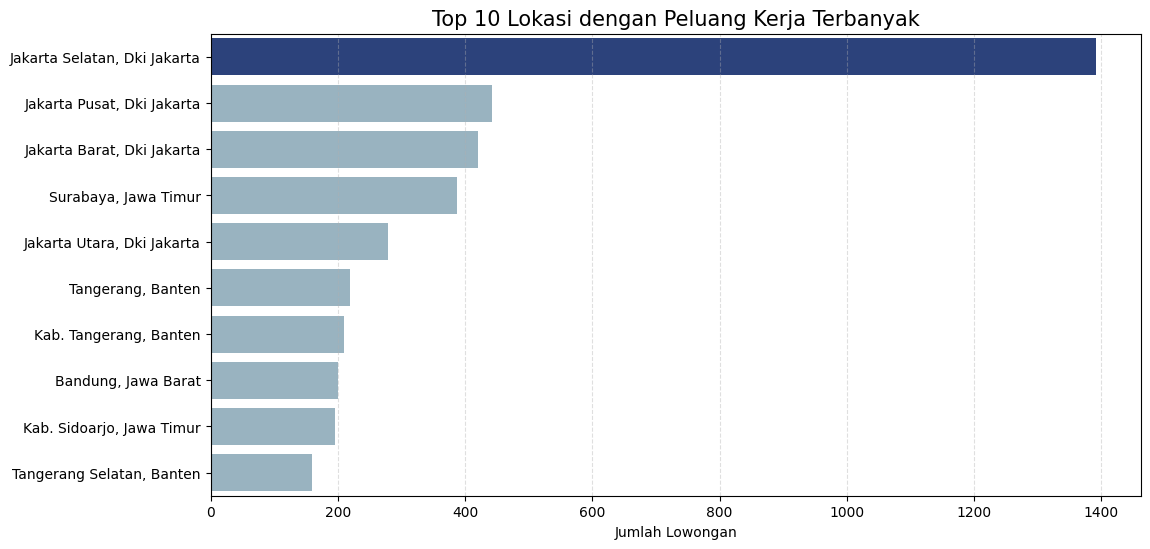

INSIGHT:
- Beberapa wilayah memiliki jumlah lowongan kerja yang lebih tinggi dibanding wilayah lainnya.
- Lokasi dengan jumlah lowongan terbesar menunjukkan pusat aktivitas industri dan perusahaan teknologi.
- Tingginya jumlah lowongan pada wilayah tertentu mengindikasikan bahwa peluang kerja di bidang IT masih terpusat di kota-kota besar.
- Persebaran peluang kerja ini dapat membantu pengguna menentukan wilayah dengan potensi karier yang lebih baik.
- Informasi lokasi lowongan juga dapat digunakan sebagai pertimbangan dalam pengembangan strategi rekrutmen dan pengembangan tenaga kerja.


In [47]:
location_df = df.groupby(by="location").agg({
    "job_title": "count"
}).reset_index()

location_df.rename(columns={
    "job_title": "total_jobs"
}, inplace=True)

top_location = location_df.sort_values(
    by="total_jobs",
    ascending=False
).head(10)

# Warna
colors = ["#1F3C88"] + ["#93B5C6"] * (len(top_location)-1)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_location,
    x="total_jobs",
    y="location",
    palette=colors
)

plt.title("Top 10 Lokasi dengan Peluang Kerja Terbanyak", fontsize=15)
plt.xlabel("Jumlah Lowongan")
plt.ylabel(None)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.show()

print("INSIGHT:")
print("- Beberapa wilayah memiliki jumlah lowongan kerja yang lebih tinggi dibanding wilayah lainnya.")
print("- Lokasi dengan jumlah lowongan terbesar menunjukkan pusat aktivitas industri dan perusahaan teknologi.")
print("- Tingginya jumlah lowongan pada wilayah tertentu mengindikasikan bahwa peluang kerja di bidang IT masih terpusat di kota-kota besar.")
print("- Persebaran peluang kerja ini dapat membantu pengguna menentukan wilayah dengan potensi karier yang lebih baik.")
print("- Informasi lokasi lowongan juga dapat digunakan sebagai pertimbangan dalam pengembangan strategi rekrutmen dan pengembangan tenaga kerja.")

### Pertanyaan 3 : Posisi pekerjaan apa yang memiliki jumlah lowongan terbanyak di pasar kerja di bidang IT saat ini?

/tmp/ipykernel_1394/1975204701.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


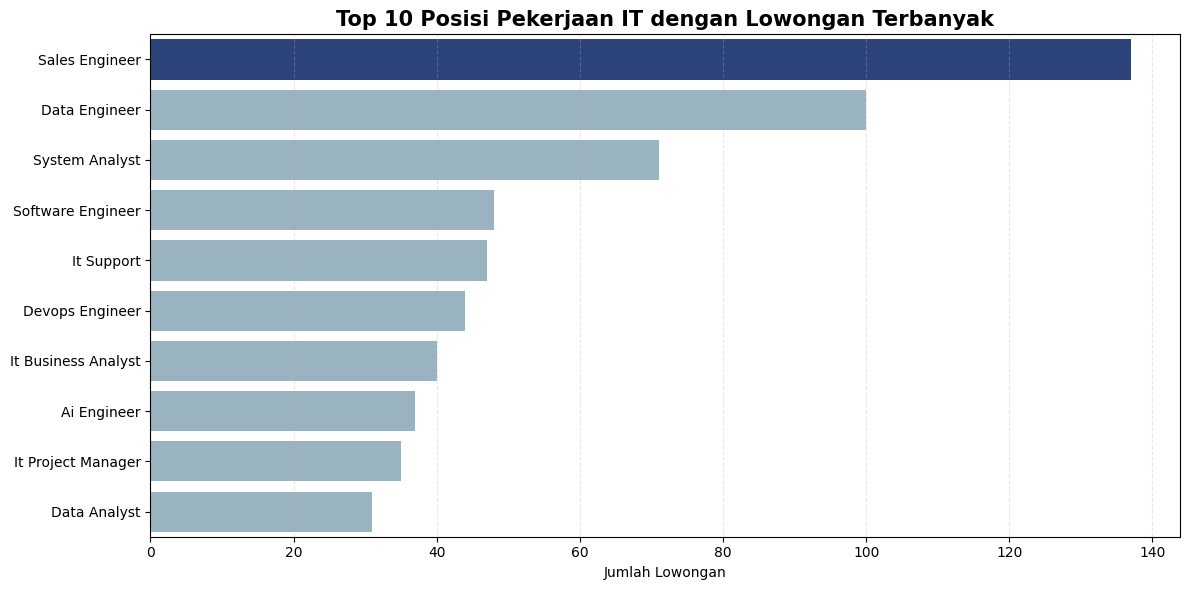

INSIGHT:
- Beberapa posisi pekerjaan memiliki jumlah lowongan yang jauh lebih tinggi dibanding posisi lainnya.
- Posisi dengan lowongan terbanyak menunjukkan tingginya kebutuhan industri terhadap peran tersebut.
- Hasil analisis ini dapat membantu pengguna menentukan pilihan karier yang memiliki peluang kerja lebih besar.
- Perusahaan cenderung lebih banyak membuka lowongan pada posisi yang berhubungan dengan transformasi digital dan pengolahan data.


In [48]:
job_df = df.groupby(by="job_title").agg({
    "company": "count"
}).reset_index()

job_df.rename(columns={
    "company": "total_jobs"
}, inplace=True)

top_jobs = job_df.sort_values(
    by="total_jobs",
    ascending=False
).head(10)

# Warna
colors = ["#1F3C88"] + ["#93B5C6"] * (len(top_jobs)-1)


# VISUALISASI
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_jobs,
    x="total_jobs",
    y="job_title",
    palette=colors
)

plt.title(
    "Top 10 Posisi Pekerjaan IT dengan Lowongan Terbanyak",
    fontsize=15,
    weight='bold'
)

plt.xlabel("Jumlah Lowongan")
plt.ylabel("")

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

# EXPLANATORY ANALYSIS
print("INSIGHT:")
print("- Beberapa posisi pekerjaan memiliki jumlah lowongan yang jauh lebih tinggi dibanding posisi lainnya.")
print("- Posisi dengan lowongan terbanyak menunjukkan tingginya kebutuhan industri terhadap peran tersebut.")
print("- Hasil analisis ini dapat membantu pengguna menentukan pilihan karier yang memiliki peluang kerja lebih besar.")
print("- Perusahaan cenderung lebih banyak membuka lowongan pada posisi yang berhubungan dengan transformasi digital dan pengolahan data.")

---
# A/B Testing: Analisis Statistik Perbedaan Platform

## Latar Belakang

Dataset berasal dari dua platform: **Glints** (Kontrol/A) dan **LinkedIn** (Perlakuan/B).
Namun jumlah datanya **sangat tidak seimbang**:
- Glints  : ~5.627 baris
- LinkedIn : ~238 baris

Ketidakseimbangan ini bisa membuat hasil Z-test menjadi bias — Glints terlalu mendominasi
sehingga test jadi terlalu sensitif, dan hasil LinkedIn kurang bisa diandalkan karena sampelnya kecil.

**Solusi: Random Undersampling**
Ambil sampel acak dari Glints sebanyak jumlah LinkedIn (238 baris), sehingga kedua grup
setara. Ini membuat perbandingannya jadi "apel vs apel", bukan "apel vs satu truk apel".

## Hipotesis

**Uji 1 — Proporsi Lowongan yang Mencantumkan Skill**
- **H₀:** Tidak ada perbedaan proporsi lowongan yang mencantumkan skill antara Glints dan LinkedIn
- **H₁:** Ada perbedaan proporsi lowongan yang mencantumkan skill antara Glints dan LinkedIn

**Uji 2 — Proporsi Lowongan yang Mensyaratkan Pendidikan S1**
- **H₀:** Tidak ada perbedaan proporsi lowongan mensyaratkan S1 antara Glints dan LinkedIn
- **H₁:** Ada perbedaan proporsi lowongan mensyaratkan S1 antara Glints dan LinkedIn

**Tingkat signifikansi (α):** 0.05
**Metode:** Z-test untuk proporsi dua sampel (`proportions_ztest`)


In [49]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns
import re

np.random.seed(42)

# Load dataset final
df_ab = pd.read_csv('all_data_final.csv')
df_ab = df_ab[df_ab['web_scraper_order'] != 'web_scraper_start_url'].copy()

# Pisahkan berdasarkan platform
glints_all  = df_ab[df_ab['source'] == 'Glints'].copy()
linkedin_all = df_ab[df_ab['source'] == 'LinkedIn'].copy()

n_linkedin = len(linkedin_all)

# ── Random Undersampling ─────────────────────────────────────────
# Ambil sampel acak dari Glints sebanyak jumlah LinkedIn
grup_A = glints_all.sample(n=n_linkedin, random_state=42).reset_index(drop=True)
grup_B = linkedin_all.reset_index(drop=True)

n_A = len(grup_A)
n_B = len(grup_B)
alpha = 0.05

print("=" * 60)
print("SETUP A/B TESTING — DENGAN RANDOM UNDERSAMPLING")
print("=" * 60)
print(f"Total data asli (Glints)   : {len(glints_all):,} baris")
print(f"Total data asli (LinkedIn) : {len(linkedin_all):,} baris")
print()
print(f"Setelah undersampling:")
print(f"  Grup A — Glints   (Kontrol)   : {n_A} baris  [sampel acak]")
print(f"  Grup B — LinkedIn (Perlakuan) : {n_B} baris  [semua data]")
print()
print(f"Kedua grup sekarang seimbang: {n_A} vs {n_B}")
print(f"Tingkat signifikansi (α)    : {alpha}")

SETUP A/B TESTING — DENGAN RANDOM UNDERSAMPLING
Total data asli (Glints)   : 5,630 baris
Total data asli (LinkedIn) : 235 baris

Setelah undersampling:
  Grup A — Glints   (Kontrol)   : 235 baris  [sampel acak]
  Grup B — LinkedIn (Perlakuan) : 235 baris  [semua data]

Kedua grup sekarang seimbang: 235 vs 235
Tingkat signifikansi (α)    : 0.05


### Uji 1: Proporsi Lowongan yang Mencantumkan Skill

In [50]:
def has_skill(text):
    """Return 1 jika skill tercantum, 0 jika tidak."""
    if not isinstance(text, str):
        return 0
    return 0 if text.strip().lower() in ['not available', '', 'nan', 'none'] else 1

grup_A['has_skill'] = grup_A['skills'].apply(has_skill)
grup_B['has_skill'] = grup_B['skills'].apply(has_skill)

konversi_A1 = grup_A['has_skill'].sum()
konversi_B1 = grup_B['has_skill'].sum()
rate_A1     = konversi_A1 / n_A
rate_B1     = konversi_B1 / n_B

print("=" * 60)
print("UJI 1: Proporsi Lowongan yang Mencantumkan Skill")
print("=" * 60)
print(f"Grup A (Glints)   : {konversi_A1} / {n_A} = {rate_A1:.4f} ({rate_A1*100:.2f}%)")
print(f"Grup B (LinkedIn) : {konversi_B1} / {n_B} = {rate_B1:.4f} ({rate_B1*100:.2f}%)")
print(f"Selisih Rate      : {(rate_B1 - rate_A1)*100:+.2f} percentage point")

z_stat1, p_val1 = proportions_ztest(
    count=[konversi_A1, konversi_B1],
    nobs=[n_A, n_B],
    alternative='two-sided'
)

print(f"\nZ-statistik : {z_stat1:.4f}")
print(f"P-value     : {p_val1:.6f}")
print(f"Alpha (α)   : {alpha}")
print()
if p_val1 < alpha:
    print(f">> TOLAK H0 — Ada perbedaan signifikan (p={p_val1:.4f} < alpha={alpha})")
    print("   Proporsi pencantuman skill antara Glints dan LinkedIn BERBEDA secara statistik.")
else:
    print(f">> GAGAL TOLAK H0 — Tidak ada perbedaan signifikan (p={p_val1:.4f} >= alpha={alpha})")
    print("   Proporsi pencantuman skill antara Glints dan LinkedIn TIDAK berbeda secara statistik.")

UJI 1: Proporsi Lowongan yang Mencantumkan Skill
Grup A (Glints)   : 235 / 235 = 1.0000 (100.00%)
Grup B (LinkedIn) : 230 / 235 = 0.9787 (97.87%)
Selisih Rate      : -2.13 percentage point

Z-statistik : 2.2481
P-value     : 0.024573
Alpha (α)   : 0.05

>> TOLAK H0 — Ada perbedaan signifikan (p=0.0246 < alpha=0.05)
   Proporsi pencantuman skill antara Glints dan LinkedIn BERBEDA secara statistik.


### Uji 2: Proporsi Lowongan yang Mensyaratkan Pendidikan S1

In [53]:
# ✅ PERBAIKAN: Ambil edu_label langsung dari kolom education
grup_A['edu_label'] = grup_A['education'].fillna('Tidak Diketahui').replace('Not Available', 'Tidak Diketahui')
grup_B['edu_label'] = grup_B['education'].fillna('Tidak Diketahui').replace('Not Available', 'Tidak Diketahui')

grup_A['req_s1'] = (grup_A['edu_label'] == 'Sarjana (S1)').astype(int)
grup_B['req_s1'] = (grup_B['edu_label'] == 'Sarjana (S1)').astype(int)

konversi_A2 = grup_A['req_s1'].sum()
konversi_B2 = grup_B['req_s1'].sum()
rate_A2     = konversi_A2 / n_A
rate_B2     = konversi_B2 / n_B

print("=" * 60)
print("UJI 2: Proporsi Lowongan yang Mensyaratkan Pendidikan S1")
print("=" * 60)
print(f"Grup A (Glints)   : {konversi_A2} / {n_A} = {rate_A2:.4f} ({rate_A2*100:.2f}%)")
print(f"Grup B (LinkedIn) : {konversi_B2} / {n_B} = {rate_B2:.4f} ({rate_B2*100:.2f}%)")
print(f"Selisih Rate      : {(rate_B2 - rate_A2)*100:+.2f} percentage point")

z_stat2, p_val2 = proportions_ztest(
    count=[konversi_A2, konversi_B2],
    nobs=[n_A, n_B],
    alternative='two-sided'
)

print(f"\nZ-statistik : {z_stat2:.4f}")
print(f"P-value     : {p_val2:.6f}")
print(f"Alpha (α)   : {alpha}")
print()
if p_val2 < alpha:
    print(f">> TOLAK H0 — Ada perbedaan signifikan (p={p_val2:.4f} < alpha={alpha})")
    print("   Proporsi syarat S1 antara Glints dan LinkedIn BERBEDA secara statistik.")
else:
    print(f">> GAGAL TOLAK H0 — Tidak ada perbedaan signifikan (p={p_val2:.4f} >= alpha={alpha})")
    print("   Proporsi syarat S1 antara Glints dan LinkedIn TIDAK berbeda secara statistik.")

UJI 2: Proporsi Lowongan yang Mensyaratkan Pendidikan S1
Grup A (Glints)   : 121 / 235 = 0.5149 (51.49%)
Grup B (LinkedIn) : 235 / 235 = 1.0000 (100.00%)
Selisih Rate      : +48.51 percentage point

Z-statistik : -12.2681
P-value     : 0.000000
Alpha (α)   : 0.05

>> TOLAK H0 — Ada perbedaan signifikan (p=0.0000 < alpha=0.05)
   Proporsi syarat S1 antara Glints dan LinkedIn BERBEDA secara statistik.


### Visualisasi Hasil A/B Testing

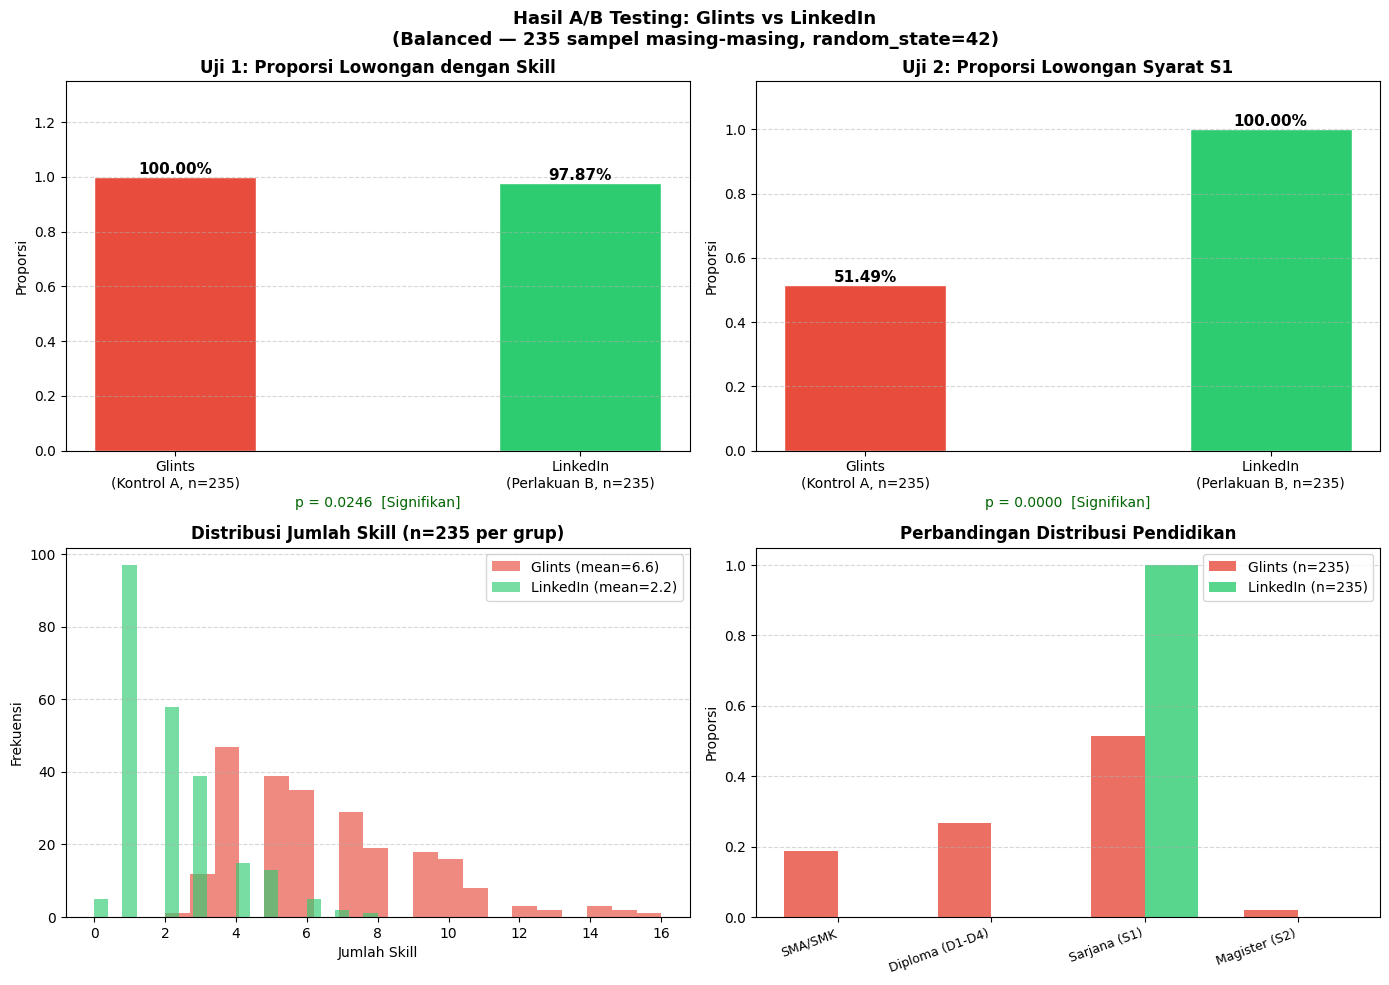

Visualisasi tersimpan: ab_testing_result.png


In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(
    f'Hasil A/B Testing: Glints vs LinkedIn\n(Balanced — {n_A} sampel masing-masing, random_state=42)',
    fontsize=13, fontweight='bold'
)

labels    = [f'Glints\n(Kontrol A, n={n_A})', f'LinkedIn\n(Perlakuan B, n={n_B})']
pal_color = ['#E74C3C', '#2ECC71']

def sig_label(p, alpha):
    if p < alpha:
        return f'p = {p:.4f}  [Signifikan]', 'darkgreen'
    return f'p = {p:.4f}  [Tidak Signifikan]', 'darkred'

# Plot 1: Bar Uji 1 — Skill
rates1 = [rate_A1, rate_B1]
bars1  = axes[0,0].bar(labels, rates1, color=pal_color, width=0.4, edgecolor='white')
axes[0,0].set_title('Uji 1: Proporsi Lowongan dengan Skill', fontweight='bold')
axes[0,0].set_ylabel('Proporsi')
axes[0,0].set_ylim(0, max(rates1) * 1.35)
axes[0,0].grid(axis='y', linestyle='--', alpha=0.5)
for bar, r in zip(bars1, rates1):
    axes[0,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{r*100:.2f}%', ha='center', fontweight='bold', fontsize=11)
sig1_text, sig1_color = sig_label(p_val1, alpha)
axes[0,0].set_xlabel(sig1_text, fontsize=10, color=sig1_color)

# Plot 2: Bar Uji 2 — S1
rates2 = [rate_A2, rate_B2]
bars2  = axes[0,1].bar(labels, rates2, color=pal_color, width=0.4, edgecolor='white')
axes[0,1].set_title('Uji 2: Proporsi Lowongan Syarat S1', fontweight='bold')
axes[0,1].set_ylabel('Proporsi')
# Guard jika kedua rate = 1.0 agar ylim tidak overflow
axes[0,1].set_ylim(0, min(max(rates2) * 1.35, 1.15))
axes[0,1].grid(axis='y', linestyle='--', alpha=0.5)
for bar, r in zip(bars2, rates2):
    axes[0,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                   f'{r*100:.2f}%', ha='center', fontweight='bold', fontsize=11)
sig2_text, sig2_color = sig_label(p_val2, alpha)
axes[0,1].set_xlabel(sig2_text, fontsize=10, color=sig2_color)

# Plot 3: Distribusi skill count per grup
def count_skills_raw(text):
    if not isinstance(text, str) or text in ['Not Available', '']:
        return 0
    parts = re.split(r'(?<=[a-z])(?=[A-Z])', text)
    return len([s for s in parts if s.strip() and len(s.strip()) > 1])

sk_a = grup_A['skills'].apply(count_skills_raw)
sk_b = grup_B['skills'].apply(count_skills_raw)
axes[1,0].hist(sk_a, bins=20, alpha=0.65, color='#E74C3C',
               label=f'Glints (mean={sk_a.mean():.1f})')
axes[1,0].hist(sk_b, bins=20, alpha=0.65, color='#2ECC71',
               label=f'LinkedIn (mean={sk_b.mean():.1f})')
axes[1,0].set_title(f'Distribusi Jumlah Skill (n={n_A} per grup)', fontweight='bold')
axes[1,0].set_xlabel('Jumlah Skill')
axes[1,0].set_ylabel('Frekuensi')
axes[1,0].legend()
axes[1,0].grid(axis='y', linestyle='--', alpha=0.5)

# Plot 4: Distribusi Pendidikan per grup
edu_order = ['SMA/SMK', 'Diploma (D1-D4)', 'Sarjana (S1)', 'Magister (S2)', 'Tidak Diketahui']
edu_A_c   = grup_A['edu_label'].value_counts()
edu_B_c   = grup_B['edu_label'].value_counts()
# Hanya tampilkan label yang muncul di salah satu grup, urut sesuai edu_order
all_edu_labels = [l for l in edu_order
                  if l in edu_A_c.index or l in edu_B_c.index]
x_pos = np.arange(len(all_edu_labels))
w = 0.35
axes[1,1].bar(x_pos - w/2,
              [edu_A_c.get(l, 0)/n_A for l in all_edu_labels],
              w, label=f'Glints (n={n_A})', color='#E74C3C', alpha=0.8)
axes[1,1].bar(x_pos + w/2,
              [edu_B_c.get(l, 0)/n_B for l in all_edu_labels],
              w, label=f'LinkedIn (n={n_B})', color='#2ECC71', alpha=0.8)
axes[1,1].set_xticks(x_pos)
axes[1,1].set_xticklabels(all_edu_labels, rotation=20, ha='right', fontsize=9)
axes[1,1].set_title('Perbandingan Distribusi Pendidikan', fontweight='bold')
axes[1,1].set_ylabel('Proporsi')
axes[1,1].legend()
axes[1,1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('ab_testing_result.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualisasi tersimpan: ab_testing_result.png")

Berikut versi **kesimpulan A/B Testing yang sudah disesuaikan dengan output terbaru dan visualisasi yang kamu tampilkan**.

---

# Kesimpulan A/B Testing

## Catatan Metodologi

Karena jumlah data lowongan dari Glints (5.630 data) jauh lebih besar dibandingkan LinkedIn (235 data), dilakukan **random undersampling** pada data Glints menggunakan `random_state=42` sehingga diperoleh 235 sampel yang dipilih secara acak. Dengan demikian, kedua grup memiliki ukuran yang sama (235 vs 235) sehingga hasil pengujian statistik tidak bias akibat ketidakseimbangan jumlah data.

Tingkat signifikansi yang digunakan pada seluruh pengujian adalah **α = 0,05**.

---

## Ringkasan Hasil

| Uji   | Metrik                                            | Grup A (Glints, n=235) | Grup B (LinkedIn, n=235) | Metode          | α    | Keputusan |
| ----- | ------------------------------------------------- | ---------------------- | ------------------------ | --------------- | ---- | --------- |
| Uji 1 | Proporsi lowongan yang mencantumkan skill         | 235/235 (100,00%)      | 230/235 (97,87%)         | Z-Test Proporsi | 0,05 | Tolak H₀  |
| Uji 2 | Proporsi lowongan yang mensyaratkan pendidikan S1 | 121/235 (51,49%)       | 235/235 (100,00%)        | Z-Test Proporsi | 0,05 | Tolak H₀  |

---

## Interpretasi Hasil

### Uji 1: Proporsi Lowongan yang Mencantumkan Skill

Hasil pengujian menunjukkan nilai **Z = 2,2481** dengan **p-value = 0,0246**. Karena p-value lebih kecil dari 0,05, maka **H₀ ditolak**.

Artinya, terdapat perbedaan yang signifikan secara statistik antara Glints dan LinkedIn dalam hal pencantuman informasi skill pada lowongan pekerjaan. Seluruh lowongan pada sampel Glints mencantumkan setidaknya satu skill (100%), sedangkan pada LinkedIn terdapat 97,87% lowongan yang mencantumkan skill.

Selain itu, distribusi jumlah skill menunjukkan bahwa Glints memiliki rata-rata **6,6 skill per lowongan**, sedangkan LinkedIn hanya **2,2 skill per lowongan**. Temuan ini mengindikasikan bahwa lowongan di Glints cenderung memberikan informasi kompetensi yang lebih lengkap dan rinci dibandingkan LinkedIn.

### Uji 2: Proporsi Lowongan yang Mensyaratkan Pendidikan S1

Hasil pengujian menunjukkan nilai **Z = -12,2681** dengan **p-value < 0,0001**. Karena p-value jauh lebih kecil dari 0,05, maka **H₀ ditolak**.

Artinya, terdapat perbedaan yang sangat signifikan secara statistik antara Glints dan LinkedIn terkait persyaratan pendidikan S1. Pada sampel yang digunakan, hanya **51,49%** lowongan di Glints yang secara eksplisit mensyaratkan pendidikan S1, sedangkan **100%** lowongan LinkedIn mensyaratkan pendidikan S1.

Distribusi pendidikan juga menunjukkan bahwa Glints menawarkan variasi persyaratan pendidikan yang lebih beragam, mencakup SMA/SMK, Diploma (D1–D4), Sarjana (S1), hingga Magister (S2). Sebaliknya, seluruh lowongan LinkedIn dalam dataset ini mensyaratkan pendidikan Sarjana (S1).

---

## Implikasi untuk CakapKarier.AI

Hasil A/B Testing menunjukkan bahwa sumber data memiliki karakteristik yang berbeda secara signifikan.

1. **Variabel `source_encoded` perlu dipertahankan dalam model machine learning**, karena platform asal lowongan terbukti memengaruhi karakteristik data yang diperoleh.
2. **Glints lebih kaya dalam informasi skill**, sehingga dapat menjadi sumber utama dalam proses ekstraksi kebutuhan kompetensi dan analisis gap skill.
3. **LinkedIn cenderung berfokus pada lowongan dengan kualifikasi pendidikan Sarjana (S1)**, sehingga dapat menjadi indikator segmen pekerjaan yang lebih formal atau profesional.
4. Perbedaan karakteristik ini perlu diperhatikan ketika membangun sistem rekomendasi karier agar hasil rekomendasi lebih akurat dan tidak bias terhadap satu platform tertentu.
5. Pengumpulan data LinkedIn dalam jumlah yang lebih besar direkomendasikan pada penelitian selanjutnya untuk meningkatkan representativitas dan generalisasi hasil analisis.

---

## Kesimpulan Akhir

Berdasarkan hasil A/B Testing, **kedua hipotesis nol (H₀) ditolak**. Terdapat perbedaan signifikan antara lowongan pekerjaan yang berasal dari Glints dan LinkedIn, baik dalam hal **kelengkapan informasi skill** maupun **persyaratan pendidikan S1**. Selain itu, Glints cenderung mencantumkan lebih banyak skill dan memiliki variasi jenjang pendidikan yang lebih beragam, sedangkan LinkedIn didominasi oleh lowongan yang mensyaratkan pendidikan Sarjana (S1). Oleh karena itu, sumber data merupakan faktor penting yang perlu dipertimbangkan dalam analisis pasar kerja dan pengembangan model rekomendasi pada CakapKarier.AI.
